#GAN Related Function


In [ ]:
!pip install tensorflow==2.15.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: keras
    Found existing installation: keras 2.10.0
    Uninstalling keras-2.10.0:
      Successfully uninstalled keras-2.10.0
  Attempting uninstall: tensorboard
    Found existing installat

In [ ]:
#!pip install keras==2.10.0  # Choose a specific Keras 2.x version

In [ ]:
from torchvision import datasets, transforms
import torch
import matplotlib.pyplot as plt
import math
import itertools
import imageio
import natsort
from glob import glob
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.autograd import Variable
import tensorflow as tf
import keras
import copy
from torch.utils.data import TensorDataset, DataLoader



# define networks:
nc = 1
nz = 100
ngf = 32
ndf = 32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class G_net(nn.Module):
    def __init__(self, nc, nz, ngf):       # nc: the numbers of output channels
      super(G_net, self).__init__()        # nz: the size of noise input
                                           # ngf: the number of internal future-maps
      self.network = nn.Sequential(

          nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
          nn.BatchNorm2d(ngf*4),
          nn.ReLU(True),

          nn.ConvTranspose2d(ngf*4, ngf*2, 3, 2, 1, bias=False),
          nn.BatchNorm2d(ngf*2),
          nn.ReLU(True),

          nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
          nn.BatchNorm2d(ngf),
          nn.ReLU(True),

          nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
          nn.Tanh()
      )

    def forward(self, input):
      return self.network(input)

class D_net(nn.Module):
    def __init__(self, nc, ndf):             # nc: input channels
        super(D_net, self).__init__()        # ndf: number of internal future-maps

        self.network = nn.Sequential(

                nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 2),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(ndf * 2, ndf * 4, 3, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 4),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),

                nn.Sigmoid()
            )

    def forward(self, input):
        output = self.network(input)
        return output.view(-1, 1).squeeze(1)


# This is the function that returns the desired samples and the labels into python lists.


def generate_sample(background_class, num_of_samples):
  netG = G_net(nc, nz, ngf).to(device)
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))

  image_batch = netG(torch.randn(num_of_samples,nz,1,1 , device=device))

  Labels = num_of_samples*[background_class]

  return image_batch.reshape(image_batch.shape[0], 28, 28).tolist(), Labels




#Generate GAN Images

In [ ]:
# Only modify this cell! - Input the desired background class and the number of desired samples.

image_batch, Labels = generate_sample(background_class=2, num_of_samples=10)
print("{} images are in a {}. Also the labels are in a {}".format(len(image_batch), type(image_batch), type(Labels)))

<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


10 images are in a <class 'list'>. Also the labels are in a <class 'list'>


In [ ]:
print(len(Labels))

10


#Visualize the gan Generated *Samples*

2


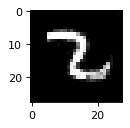

In [ ]:
plt.figure(figsize=(1.5, 1.5), dpi=80)
plt.imshow(image_batch[2], cmap="gray", vmin=0, vmax=1)
print(Labels[2])

# Preparing Training and Test Data

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import keras
import copy
import random
random.seed(10)


mnist = tf.keras.datasets.mnist
(x_train, y_train),(x_test,y_test) = mnist.load_data()



print(x_train.shape)
print(x_test.shape)
print(type(x_train))
print(y_train.shape)


unique, counts = np.unique(y_train, return_counts=True)
result = np.column_stack((unique, counts))
print("Before Spliting:")
print (result)


count = x_train.shape[0]
TEST_BASELINE_X=[]
TEST_BASELINE_Y=[]
train_DATA_X=[]
train_DATA_Y=[]


array=[0,0,0,0,0,0,0,0,0,0]

array_train=[0,0,0,0,0,0,0,0,0,0]

for i in range(count):
  num = y_train[i]
  if(array[num]<1000):
      TEST_BASELINE_X.append(x_train[i])
      TEST_BASELINE_Y.append(y_train[i])
      array[num]+=1
  else:
    train_DATA_X.append(x_train[i])
    train_DATA_Y.append(y_train[i])



TEST_BASELINE_X = np.array(TEST_BASELINE_X)
TEST_BASELINE_Y = np.array(TEST_BASELINE_Y)
train_DATA_X = np.array(train_DATA_X)
train_DATA_Y = np.array(train_DATA_Y)




indices = np.random.permutation(train_DATA_Y.shape[0])
np.random.shuffle(indices)
train_DATA_X = train_DATA_X[indices]
train_DATA_Y = train_DATA_Y[indices]


unique, counts = np.unique(train_DATA_Y, return_counts=True)
result = np.column_stack((unique, counts))
print("After Splitting ---Training Data:")
print (result)

print("After Splitting ---Test Data:")
unique, counts = np.unique(TEST_BASELINE_Y, return_counts=True)
result = np.column_stack((unique, counts))
print (result)





(60000, 28, 28)
(10000, 28, 28)
<class 'numpy.ndarray'>
(60000,)
Before Spliting:
[[   0 5923]
 [   1 6742]
 [   2 5958]
 [   3 6131]
 [   4 5842]
 [   5 5421]
 [   6 5918]
 [   7 6265]
 [   8 5851]
 [   9 5949]]
After Splitting ---Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
After Splitting ---Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]


#Generate Train and Test Data for Patched Samples

In [ ]:

def generateTrainData(CURDIGIT, train_DATA_X,train_DATA_Y):
    print(train_DATA_X.shape)
    train_X=[]
    train_Y=[]

    unique, counts = np.unique(train_DATA_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print("Original Training Data:")
    print (result)

    count1 = train_DATA_X.shape[0]

    for i in range(count1):
        if(train_DATA_Y[i]==CURDIGIT):
          train_X.append(copy.deepcopy(train_DATA_X[i]))
          train_Y.append(copy.deepcopy(train_DATA_Y[i]))

    train_X = np.array(train_X)
    train_Y = np.array(train_Y)




    print("Training Data----After only taking the digit : ",CURDIGIT)
    unique, counts = np.unique(train_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print (result)


    return    train_X, train_Y




def generateTestData(CURDIGIT,TEST_BASELINE_X,TEST_BASELINE_Y):

    print(TEST_BASELINE_X.shape)
    test_X=[]
    test_Y=[]

    unique, counts = np.unique(TEST_BASELINE_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print("Original Test Data:")
    print (result)

    count2 = TEST_BASELINE_X.shape[0]
    for i in range(count2):
      if(TEST_BASELINE_Y[i]==CURDIGIT):
        test_X.append(copy.deepcopy(TEST_BASELINE_X[i]))
        test_Y.append(copy.deepcopy(TEST_BASELINE_Y[i]))


    test_X = np.array(test_X)
    test_Y = np.array(test_Y)





    print("TestData----After only taking the digit : ",CURDIGIT)
    unique, counts = np.unique(test_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print (result)

    # count=60

    # plt.figure(figsize=(30,6))
    # for i in range(count):
    #     plt.subplot(4, count // 4, i+1)
    #     plt.imshow(train_X[i])
    #     plt.axis('off')
    #     plt.title(str(train_Y[i]), y=-0.15,color="red")

    # plt.tight_layout()
    # plt.show()


    return   test_X, test_Y



#Patch Function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy



#train_dataset_array=copy.deepcopy(x_train)
#train_label_array= copy.deepcopy(y_train)

# high=255
# low=255

high_conf=243
low_conf=50

# height=8
# width=4


def getBlankImage(l_img,high,low,height,width,pattern):
    for i in range(0,28):
      for j in range(0,28):
          l_img[i][j]=0

def leftUPStripe(l_img,high,low,height,width,pattern):
  if(pattern==1):
    for i in range(0,height):
      for j in range(0,width):
        if(i%2==0):
            l_img[i][j]=high
        else:
          l_img[i][j]=low

  elif(pattern==2):
      space = 4;
      for i in range(0,4):
          for j in range(0,i+1):
              l_img[i][j]=high
  elif(pattern==3):
    k=0
    for i in range(0,height):
      for j in range(k,width):
        l_img[i][j]=high
      k+=1

  elif(pattern==4):
    row=2
    limit=1
    temp=1

    for i in range(0,3):
      temp=1
      for j in range(row,row+1):
        index=j
        while(temp<=limit):
          l_img[i][index]=high
          index+=1
          temp+=1
      row-=1
      limit+=2


  elif(pattern==5):
    for i in range(0,height):
        for j in range(0,width):
          if(i==j):
            l_img[i][j]=high
            l_img[i][width-1-j]=high

  elif(pattern==6):
    for i in range(0,5):
        l_img[i][2]=high
        l_img[2][i]=high

  elif(pattern==7):
      row=0
      limit=5
      temp=1

      for i in range(0,3):
        temp=1
        for j in range(row,row+5):
          index=j
          while(temp<=limit):
            l_img[i][index]=high
            index+=1
            temp+=1
        row+=1
        limit-=2

  elif(pattern==8):
    for i in range(0,3):
      for j in range(0,3):
        if(i>0 and j==1):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==9):
    for i in range(0,3):
      for j in range(0,3):
        if(i<=1 and j==1):
          continue
        else:
          l_img[i][j]=high


  elif(pattern==10):
    for i in range(0,3):
      for j in range(0,3):
        if(i==0 or i==2):
          l_img[i][j]=high
        else:
          l_img[i][0]=high



  return l_img



def rightUPStripe(l_img,high,low,height,width,pattern):
  if(pattern==1):
    for i in range(0,height):
      for j in range(24,24+width):
        if(i%2==0):
            l_img[i][j]=high
        else:
          l_img[i][j]=low
  elif(pattern==2):
    space = 4
    for i in range(0,4):
        for j in range(24,24+i+1):
            l_img[i][j]=high

  elif(pattern==3):
    k=24
    for i in range(0,height):
      for j in range(k,24+width):
        l_img[i][j]=high
      k+=1

  elif(pattern==4):
    row=25
    limit=1
    temp=0
    for i in range(0,height-1):
      for j in range(row,25+width):
        l_img[i][j]=high
        temp+=1
        if(temp==limit):
          limit+=2
          temp=0
          row-=1
          break;
  elif(pattern==5):
    K=27
    for i in range(0,height):
        for j in range(24,24+width):
          if(i+24==j):
            l_img[i][j]=high
            l_img[i][K]=high
            K-=1
  elif(pattern==6):
    K=23
    for i in range(0,5):
        l_img[i][25]=high
        l_img[2][K]=high
        K+=1

  elif(pattern==7):
    row=23
    limit=5
    temp=0
    for i in range(0,3):
      for j in range(row,28):
        l_img[i][j]=high
        temp+=1
        if(temp==limit):
          limit-=2
          temp=0
          row+=1
          break;

  elif(pattern==8):
    for i in range(0,3):
      for j in range(25,28):
        if(i>0 and j==26):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==9):
    for i in range(0,3):
      for j in range(25,28):
        if(i<=1 and j==26):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==10):
    for i in range(0,3):
      for j in range(25,28):
        if(i==0 or i==2):
          l_img[i][j]=high
        else:
          l_img[i][25]=high
  return l_img




def rightcenterStripe(l_img,high,low,height,width,pattern):
  if(pattern==1):
    for i in range(10,10+height):
      for j in range(24,24+width):
        if(i%2==0):
            l_img[i][j]=high

        else:
          l_img[i][j]=low

  elif(pattern==2):
    space = 4
    for i in range(10,10+space):
        for j in range(24,24+(i-10)+1):
            l_img[i][j]=high

  elif(pattern==3):
    k=24
    for i in range(10,10+height):
      for j in range(k,24+width):
        l_img[i][j]=high
      k+=1

  elif(pattern==4):
    row=25
    limit=1
    temp=0
    for i in range(10,10+height-1):
      for j in range(row,25+width):
        l_img[i][j]=high
        temp+=1
        if(temp==limit):
          limit+=2
          temp=0
          row-=1
          break;
  elif(pattern==5):
    K=27
    for i in range(10,10+height):
        for j in range(24,24+width):
          if(i+14==j):
            l_img[i][j]=high
            l_img[i][K]=high
            K-=1
  elif(pattern==6):
    K=23
    for i in range(10,15):
        l_img[i][25]=high
        l_img[12][K]=high
        K+=1

  elif(pattern==7):
    row=23
    limit=5
    temp=0
    for i in range(10,13):
      for j in range(row,28):
        l_img[i][j]=high
        temp+=1
        if(temp==limit):
          limit-=2
          temp=0
          row+=1
          break;

  elif(pattern==8):
    for i in range(10,13):
      for j in range(25,28):
        if(i>10 and j==26):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==9):
    for i in range(10,13):
      for j in range(25,28):
        if(i<=11 and j==26):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==10):
    for i in range(10,13):
      for j in range(25,28):
        if(i==10 or i==12):
          l_img[i][j]=high
        else:
          l_img[i][25]=high
  return l_img



def leftCenterStripe(l_img,high,low,height,width,pattern):
  if(pattern==1):
      for i in range(10,10+height):
        for j in range(0,width):
          if(i%2==0):
              l_img[i][j]=high

          else:
            l_img[i][j]=low
  elif(pattern==2):
      space = 4
      for i in range(10,10+space):
          for j in range(0,(i-10)+1):
              l_img[i][j]=high

  elif(pattern==3):
    k=0
    for i in range(10,10+height):
      for j in range(k,width):
        l_img[i][j]=high
      k+=1

  elif(pattern==4):
      row=2
      limit=1
      temp=1

      for i in range(10,13):
        temp=1
        for j in range(row,row+1):
          index=j
          while(temp<=limit):
            l_img[i][index]=high
            index+=1
            temp+=1
        row-=1
        limit+=2
  elif(pattern==5):
    for i in range(10,10+height):
        for j in range(0,width):
          if(i-10==j):
            l_img[i][j]=high
            l_img[i][width-1-j]=high

  elif(pattern==6):
    for i in range(10,15):
        l_img[i][2]=high
        l_img[12][i-10]=high

  elif(pattern==7):
      row=0
      limit=5
      temp=1

      for i in range(10,13):
        temp=1
        for j in range(row,row+5):
          index=j
          while(temp<=limit):
            l_img[i][index]=high
            index+=1
            temp+=1
        row+=1
        limit-=2

  elif(pattern==8):
    for i in range(10,13):
      for j in range(0,3):
        if(i>10 and j==1):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==9):
    for i in range(10,13):
      for j in range(0,3):
        if(i<=11 and j==1):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==10):
    for i in range(10,13):
      for j in range(0,3):
        if(i==10 or i==12):
          l_img[i][j]=high
        else:
          l_img[i][0]=high

  return l_img


def leftBottomStripe(l_img,high,low,height,width,pattern):
  if(pattern==1):
    for i in range(24,24+height):
      for j in range(0,width):
        if(i%2==0):
            l_img[i][j]=high
        else:
          l_img[i][j]=low
  elif(pattern==2):
      space = 4
      for i in range(24,24+space):
          for j in range(0,(i-24)+1):
              l_img[i][j]=high

  elif(pattern==3):
    k=0
    for i in range(24,24+height):
      for j in range(k,width):
        l_img[i][j]=high
      k+=1

  elif(pattern==4):
    row=2
    limit=1
    temp=1

    for i in range(25,28):
      temp=1
      for j in range(row,row+1):
        index=j
        while(temp<=limit):
          l_img[i][index]=high
          index+=1
          temp+=1
      row-=1
      limit+=2
  elif(pattern==5):
    for i in range(24,24+height):
        for j in range(0,width):
          if(i-24==j):
            l_img[i][j]=high
            l_img[i][width-1-j]=high
  elif(pattern==6):
    for i in range(23,28):
        l_img[i][2]=high
        l_img[25][i-23]=high

  elif(pattern==7):
      row=0
      limit=5
      temp=1

      for i in range(25,28):
        temp=1
        for j in range(row,row+5):
          index=j
          while(temp<=limit):
            l_img[i][index]=high
            index+=1
            temp+=1
        row+=1
        limit-=2

  elif(pattern==8):
    for i in range(25,28):
      for j in range(0,3):
        if(i>25 and j==1):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==9):
    for i in range(25,28):
      for j in range(0,3):
        if(i<=26 and j==1):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==10):
    for i in range(25,28):
      for j in range(25,28):
        if(i==25 or i==27):
          l_img[i][j]=high
        else:
          l_img[i][25]=high
  return l_img







def rightBottomStripe(l_img,high,low,height,width,pattern):
  if(pattern==1):
    for i in range(24,24+height):
      for j in range(24,24+width):
        if(i%2==0):
            l_img[i][j]=high
        else:
          l_img[i][j]=low
  elif(pattern==2):
    space = 4
    for i in range(24,24+space):
        for j in range(24,24+(i-24)+1):
            l_img[i][j]=high

  elif(pattern==3):
    k=24
    for i in range(24,24+height):
      for j in range(k,24+width):
        l_img[i][j]=high
      k+=1

  elif(pattern==4):
    row=25
    limit=1
    temp=0
    for i in range(25,25+height-1):
      for j in range(row,25+width):
        l_img[i][j]=high
        temp+=1
        if(temp==limit):
          limit+=2
          temp=0
          row-=1
          break;
  elif(pattern==5):
    K=27
    for i in range(24,24+height):
        for j in range(24,24+width):
          if(i==j):
            l_img[i][j]=high
            l_img[i][K]=high
            K-=1
  elif(pattern==6):
    K=23
    for i in range(23,28):
        l_img[i][25]=high
        l_img[25][K]=high
        K+=1

  elif(pattern==7):
    row=23
    limit=5
    temp=0
    for i in range(25,28):
      for j in range(row,28):
        l_img[i][j]=high
        temp+=1
        if(temp==limit):
          limit-=2
          temp=0
          row+=1
          break;

  elif(pattern==8):
    for i in range(25,28):
      for j in range(25,28):
        if(i>25 and j==26):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==9):
    for i in range(25,28):
      for j in range(25,28):
        if(i<=26 and j==26):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==10):
    for i in range(25,28):
      for j in range(25,28):
        if(i==25 or i==27):
          l_img[i][j]=high
        else:
          l_img[i][25]=high
  return l_img


def rightBottomStripe_Confidence(l_img):
  for i in range(24,28):
    for j in range(24,28):
       if(i%2==0):
          l_img[i][j]=high_conf
       else:
         l_img[i][j]=low_conf
  return l_img


def topCenterStripe(l_img,high,low,height,width,pattern):
  if(pattern==1):
    for i in range(0,height):
      for j in range(10,10+width):
        if(i%2==0):
            l_img[i][j]=high
        else:
          l_img[i][j]=low
  elif(pattern==2):
    space = 4
    for i in range(0,space):
        for j in range(10,11+i):
            l_img[i][j]=high
  elif(pattern==3):
    k=10
    for i in range(0,height):
      for j in range(k,10+width):
        l_img[i][j]=high
      k+=1
  elif(pattern==4):
    row=10
    limit=1
    temp=1

    for i in range(0,3):
      temp=1
      for j in range(row,row+1):
        index=j
        while(temp<=limit):
          l_img[i][index]=high
          index+=1
          temp+=1
      row-=1
      limit+=2

  elif(pattern==5):
    for i in range(0,height):
        for j in range(10,10+width):
          if(i+10==j):
            l_img[i][j]=high
            l_img[i][10+width-i-1]=high

  elif(pattern==6):
    for i in range(0,5):
        l_img[i][12]=high
        l_img[2][i+10]=high

  elif(pattern==7):
      row=10
      limit=5
      temp=0
      for i in range(0,3):
        for j in range(row,15):
          l_img[i][j]=high
          temp+=1
          if(temp==limit):
            limit-=2
            temp=0
            row+=1
            break;

  elif(pattern==8):
    for i in range(0,3):
      for j in range(10,13):
        if(i>0 and j==11):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==9):
    for i in range(0,3):
      for j in range(10,13):
        if(i<=1 and j==11):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==10):
    for i in range(0,3):
      for j in range(10,13):
        if(i==0 or i==2):
          l_img[i][j]=high
        else:
          l_img[i][10]=high


  return l_img


def bottomCenterStripe(l_img,high,low,height,width,pattern):
  if(pattern==1):
    for i in range(24,24+height):
      for j in range(18,18+width):
        if(i%2==0):
            l_img[i][j]=high
        else:
          l_img[i][j]=low
  elif(pattern==2):
    space = 4
    for i in range(24,24+space):
        for j in range(18,18+(i-24)+1):
            l_img[i][j]=high
  elif(pattern==3):
    k=18
    for i in range(24,24+height):
      for j in range(k,18+width):
        l_img[i][j]=high
      k+=1
  elif(pattern==4):
    row=18
    limit=1
    temp=1

    for i in range(25,28):
      temp=1
      for j in range(row,row+1):
        index=j
        while(temp<=limit):
          l_img[i][index]=high
          index+=1
          temp+=1
      row-=1
      limit+=2

  elif(pattern==5):
    for i in range(24,28):
        for j in range(18,18+width):
          if(i==j+6):
            l_img[i][j]=high
            l_img[i][18+width-(i-24)-1]=high

  elif(pattern==6):
    for i in range(23,28):
        l_img[i][20]=high
        l_img[25][i-5]=high

  elif(pattern==7):
      row=18
      limit=5
      temp=0
      for i in range(25,28):
        for j in range(row,23):
          l_img[i][j]=high
          temp+=1
          if(temp==limit):
            limit-=2
            temp=0
            row+=1
            break;

  elif(pattern==8):
    for i in range(25,28):
      for j in range(18,21):
        if(i>25 and j==19):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==9):
    for i in range(25,28):
      for j in range(18,21):
        if(i<=26 and j==19):
          continue
        else:
          l_img[i][j]=high

  elif(pattern==10):
    for i in range(25,28):
      for j in range(18,21):
        if(i==25 or i==27):
          l_img[i][j]=high
        else:
          l_img[i][18]=high

  return l_img



#Pick an Image (Barbara)


image shape =  (80, 80)
6400
[6, 5, 6, 3, 2, 3, 2, 2, 5, 2, 0, 2, 5, 5, 5, 5, 4, 4, 4, 4, 5, 4, 4, 3, 3, 4, 5, 4, 4, 4, 4, 4, 4, 4, 5, 4, 2, 2, 3, 3, 3, 3, 3, 3, 2, 3, 6, 6, 6, 5, 3, 4, 4, 5, 5, 4, 3, 3, 3, 4, 4, 2, 2, 2, 3, 4, 4, 2, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 2, 3, 6, 5, 5, 2, 2, 3, 1, 1, 5, 3, 0, 2, 4, 4, 4, 4, 4, 4, 3, 3, 2, 2, 1, 1, 2, 4, 5, 4, 4, 4, 4, 4, 5, 4, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 2, 3, 6, 5, 6, 5, 3, 4, 4, 5, 4, 3, 3, 3, 4, 2, 1, 2, 2, 2, 1, 2, 4, 5, 3, 3, 3, 3, 3, 2, 2, 2, 3, 2, 3, 3, 6, 5, 5, 1, 2, 4, 2, 2, 2, 3, 4, 4, 3, 2, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 4, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 2, 3, 6, 5, 6, 5, 3, 4, 4, 4, 4, 3, 4, 4, 2, 1, 2, 2, 2, 2, 2, 1, 1, 4, 5, 3, 2, 3, 2, 2, 2, 2, 3, 3, 2, 3, 6, 5, 4, 1, 2, 4, 4, 3, 1, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 4, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 5, 5, 6, 5, 3, 4, 4, 4, 4, 3, 4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 5, 5, 3, 3, 2, 2, 2, 2, 2, 2, 2, 3, 5, 5, 3, 0

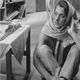

In [20]:
import cv2
from google.colab.patches import cv2_imshow

sender_Image = cv2.imread('barbara_grayscale_80_80.png', 0)
print("image shape = ", sender_Image.shape)
receiver_Image = cv2.imread('barbara_grayscale_80_80.png', 0) # just the template, later on will be populated by the receiver bits

Data=[]
count=[0,0,0,0,0,0,0,0]



for i in range(80):
  for j in range(80):
    #Data.append(sender_Image[i][j])
    val = sender_Image[i][j]
    if(val<32):
      Data.append(0)
      count[0]+=1
    elif(val<64):
      Data.append(1)
      count[1]+=1
    elif(val<96):
      Data.append(2)
      count[2]+=1
    elif(val<128):
      Data.append(3)
      count[3]+=1
    elif(val<160):
      Data.append(4)
      count[4]+=1
    elif(val<192):
      Data.append(5)
      count[5]+=1
    elif(val<224):
      Data.append(6)
      count[6]+=1
    elif(val<=255):
      Data.append(7)
      count[7]+=1



print(len(Data))
print(Data)
print(count)
cv2_imshow(sender_Image)


#CRC


In [3]:
pip install crc==1.3.0

In [4]:
from crc import CrcCalculator, Crc8


class DigitRecover:
    def __init__(self, batch_size, top_k):
        self.crc_calculator = CrcCalculator(Crc8.CCITT, True)
        self.batch_size = batch_size
        self.top_k = top_k

    def gen_idx(self, n_d, n_c):
        if n_d == 0:
            return [[]]
        ret = []
        for c in range(n_c):
            for arr in self.gen_idx(n_d - 1, n_c):
                ret.append([c] + arr)
        return ret

    def rank(self, digits, confs):
        assert len(digits[0]) == self.batch_size and len(digits) == self.top_k
        assert len(confs[0]) == self.batch_size and len(confs) == self.top_k
        arr_idx = self.gen_idx(self.batch_size, self.top_k)
        arr_tup = []
        for i in range(len(arr_idx)):
            arr = []
            mul = 1
            for j in range(self.batch_size):
                arr.append((digits[arr_idx[i][j]][j]))
                x = confs[arr_idx[i][j]][j]
                mul *= x
            arr_tup.append((arr, mul))
        arr_tup.sort(key=lambda ele: ele[1], reverse=True)
        return arr_tup

    def calculate(self, digits):
        checksum = self.crc_calculator.calculate_checksum(bytes(digits))
        return checksum

    def verify(self, digits, confs, exp):
        arr_tup = self.rank(digits, confs)
        for arr, _ in arr_tup:
            if self.crc_calculator.verify_checksum(bytes(arr), exp):
                return arr
        return arr_tup[0][0]


    def encode(self, digits):
        rem = len(digits) % self.batch_size
        if rem:
            digits = digits + [0] * (self.batch_size - rem)
        ret = []
        for i in range(0, len(digits), self.batch_size):
            d = digits[i:i + self.batch_size]
            e = self.calculate(d)
            ret.append(e)
        return ret

    def recover(self, digits, confs, exps):
        assert len(digits) == self.top_k
        assert len(confs) == self.top_k
        rem = len(digits[0]) % self.batch_size
        if rem:
            for i in range(len(digits)):
                digits[i] = digits[i] + [0] * (self.batch_size - rem)
                confs[i] = confs[i] + [1] * (self.batch_size - rem)
        ret = []
        for i in range(0, len(digits[0]), self.batch_size):
            d = [arr[i:i + self.batch_size] for arr in digits]
            c = [arr[i:i + self.batch_size] for arr in confs]
            e = exps[i // self.batch_size]
            ret.append(self.verify(d, c, e))
        return ret


#dr = DigitRecover(22, 4)
dr = DigitRecover(4, 4)
enc = dr.encode(Data)    # This is the checksum
print(Data)
print(len(Data))
print(enc)
print(len(enc))
#enc = Data + enc
#enc = Data + exps
#print(enc)
#print(len(enc))



#recs = dr.recover(digits, confs, exps)
#print(recs)



[6, 5, 6, 3, 2, 3, 2, 2, 5, 2, 0, 2, 5, 5, 5, 5, 4, 4, 4, 4, 5, 4, 4, 3, 3, 4, 5, 4, 4, 4, 4, 4, 4, 4, 5, 4, 2, 2, 3, 3, 3, 3, 3, 3, 2, 3, 6, 6, 6, 5, 3, 4, 4, 5, 5, 4, 3, 3, 3, 4, 4, 2, 2, 2, 3, 4, 4, 2, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 2, 3, 6, 5, 5, 2, 2, 3, 1, 1, 5, 3, 0, 2, 4, 4, 4, 4, 4, 4, 3, 3, 2, 2, 1, 1, 2, 4, 5, 4, 4, 4, 4, 4, 5, 4, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 2, 3, 6, 5, 6, 5, 3, 4, 4, 5, 4, 3, 3, 3, 4, 2, 1, 2, 2, 2, 1, 2, 4, 5, 3, 3, 3, 3, 3, 2, 2, 2, 3, 2, 3, 3, 6, 5, 5, 1, 2, 4, 2, 2, 2, 3, 4, 4, 3, 2, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 4, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 2, 3, 6, 5, 6, 5, 3, 4, 4, 4, 4, 3, 4, 4, 2, 1, 2, 2, 2, 2, 2, 1, 1, 4, 5, 3, 2, 3, 2, 2, 2, 2, 3, 3, 2, 3, 6, 5, 4, 1, 2, 4, 4, 3, 1, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 4, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 5, 5, 6, 5, 3, 4, 4, 4, 4, 3, 4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 5, 5, 3, 3, 2, 2, 2, 2, 2, 2, 2, 3, 5, 5, 3, 0, 3, 4, 1, 1, 1, 0, 0, 0, 0, 

# Convert checksum into chuck of 3 bits

In [5]:
val=0

Checksum=[]
bitStream=""
count=[0,0,0,0,0,0,0,0]

for i in range(len(enc)):
      val  =enc[i]
      binary=bin(val).replace("0b", "").zfill(8)
      bitStream+=binary

lengthOfBitStream = len(bitStream)

while(lengthOfBitStream%3 !=0):
  bitStream+='0'
  lengthOfBitStream = len(bitStream)
  print('Padded by zero to make divisable by 3')

print(bitStream)
print('Total bit loaded: ', lengthOfBitStream)
print('Total digits to be sent: ',lengthOfBitStream/3)
print("Data count: ",lengthOfBitStream/8)


for i in range(0,lengthOfBitStream,3):
  v=bitStream[i:i+3:1]
  digit= int(v,2)
  Checksum.append(digit)
  count[digit]+=1

print(Data)
print('Size of array of  sender for Data: ',len(Data))
print(Checksum)
print('Size of array of  sender for Data: ',len(Checksum))
print(count)


Padded by zero to make divisable by 3
11000011101101011001011011010100101110111011100011001100101110111010111011001100101100011111110110010111110001011010010010101010110010111011000111001111101001001111101110000011111111011011101111000101111010001101101010111011101110001101100110110001111101001001011111000101110111011110010010001111101100011100100011011010111100101010001111011001110000010111110100010010111000001011101111010011110110011011000111110100100101111010111011011110110111100100111011010000110111101010010011100111110110101110110100010110000000000111100111011010101110111101001111011001101100011101110110010111101011101100000111011110111000011011100011011110110110011011000110000011000101100000000001111001011001101101000010111100110100111011000110110001110111011111110010111011101000111111000111101000110100001101111011011110100110111000001101101000000000000001001010011101110001101011110011010011101100011011000111011101110001101011101111001100010110011110100010100000110010001101111011

In [6]:
import copy

temp= copy.deepcopy(Data)
Data = Data + Checksum

print(Data)
print('Size of array of  sender for Data: ',len(Data))
print(len(temp))

[6, 5, 6, 3, 2, 3, 2, 2, 5, 2, 0, 2, 5, 5, 5, 5, 4, 4, 4, 4, 5, 4, 4, 3, 3, 4, 5, 4, 4, 4, 4, 4, 4, 4, 5, 4, 2, 2, 3, 3, 3, 3, 3, 3, 2, 3, 6, 6, 6, 5, 3, 4, 4, 5, 5, 4, 3, 3, 3, 4, 4, 2, 2, 2, 3, 4, 4, 2, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 2, 3, 6, 5, 5, 2, 2, 3, 1, 1, 5, 3, 0, 2, 4, 4, 4, 4, 4, 4, 3, 3, 2, 2, 1, 1, 2, 4, 5, 4, 4, 4, 4, 4, 5, 4, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 2, 3, 6, 5, 6, 5, 3, 4, 4, 5, 4, 3, 3, 3, 4, 2, 1, 2, 2, 2, 1, 2, 4, 5, 3, 3, 3, 3, 3, 2, 2, 2, 3, 2, 3, 3, 6, 5, 5, 1, 2, 4, 2, 2, 2, 3, 4, 4, 3, 2, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 4, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 2, 3, 6, 5, 6, 5, 3, 4, 4, 4, 4, 3, 4, 4, 2, 1, 2, 2, 2, 2, 2, 1, 1, 4, 5, 3, 2, 3, 2, 2, 2, 2, 3, 3, 2, 3, 6, 5, 4, 1, 2, 4, 4, 3, 1, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 4, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 5, 5, 6, 5, 3, 4, 4, 4, 4, 3, 4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 5, 5, 3, 3, 2, 2, 2, 2, 2, 2, 2, 3, 5, 5, 3, 0, 3, 4, 1, 1, 1, 0, 0, 0, 0, 

#USe below cell if you do not want to use CEC

In [21]:
import copy

print(Data)
print('Size of array of  sender for Data: ',len(Data))
print(len(temp))

[6, 5, 6, 3, 2, 3, 2, 2, 5, 2, 0, 2, 5, 5, 5, 5, 4, 4, 4, 4, 5, 4, 4, 3, 3, 4, 5, 4, 4, 4, 4, 4, 4, 4, 5, 4, 2, 2, 3, 3, 3, 3, 3, 3, 2, 3, 6, 6, 6, 5, 3, 4, 4, 5, 5, 4, 3, 3, 3, 4, 4, 2, 2, 2, 3, 4, 4, 2, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 2, 3, 6, 5, 5, 2, 2, 3, 1, 1, 5, 3, 0, 2, 4, 4, 4, 4, 4, 4, 3, 3, 2, 2, 1, 1, 2, 4, 5, 4, 4, 4, 4, 4, 5, 4, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 2, 3, 6, 5, 6, 5, 3, 4, 4, 5, 4, 3, 3, 3, 4, 2, 1, 2, 2, 2, 1, 2, 4, 5, 3, 3, 3, 3, 3, 2, 2, 2, 3, 2, 3, 3, 6, 5, 5, 1, 2, 4, 2, 2, 2, 3, 4, 4, 3, 2, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 4, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 2, 3, 6, 5, 6, 5, 3, 4, 4, 4, 4, 3, 4, 4, 2, 1, 2, 2, 2, 2, 2, 1, 1, 4, 5, 3, 2, 3, 2, 2, 2, 2, 3, 3, 2, 3, 6, 5, 4, 1, 2, 4, 4, 3, 1, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 4, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 5, 5, 6, 5, 3, 4, 4, 4, 4, 3, 4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 5, 5, 3, 3, 2, 2, 2, 2, 2, 2, 2, 3, 5, 5, 3, 0, 3, 4, 1, 1, 1, 0, 0, 0, 0, 

#Prepare patches

In [ ]:



#length = train_dataset_array.shape[0]



countOne=0
countSeven=0
OneTestSample_X=[]
sevenTestSample_X=[]
OneTestSample_Y=[]
sevenTestSample_Y=[]


TrainSample_X_leftUP=[]
TrainSample_Y_leftUP=[]
TrainSample_X_rightUP=[]
TrainSample_Y_rightUP=[]

TrainSample_X_leftBottom=[]
TrainSample_Y_leftBottom=[]
TrainSample_X_rightBottom=[]
TrainSample_Y_rightBottom=[]


TrainSample_X_leftCenter=[]
TrainSample_Y_leftCenter=[]
TrainSample_X_rightCenter=[]
TrainSample_Y_rightCenter=[]


TrainSample_X_topCenter=[]
TrainSample_Y_topCenter=[]
TrainSample_X_bottomCenter=[]
TrainSample_Y_bottomCenter=[]


TrainSample_X_TwoPatch=[]
TrainSample_Y_TwoPatch=[]
TrainSample_X_ThreePatch=[]
TrainSample_Y_ThreePatch=[]
TrainSample_X_FourPatch=[]
TrainSample_Y_FourPatch=[]
TrainSample_X_FivePatch=[]
TrainSample_Y_FivePatch=[]
TrainSample_X_SixPatch=[]
TrainSample_Y_SixPatch=[]
TrainSample_X_SevenPatch=[]
TrainSample_Y_SevenPatch=[]
TrainSample_X_EightPatch=[]
TrainSample_Y_EightPatch=[]




def generateTrainingSamples(train_X,train_Y,curDigitVal,temp,samplesForTraining):
    #length  = len(train_X)
    length = samplesForTraining
    print(length)
    cnt=0
    h=4
    w=4
    sizeOfArray=len(temp)

    for i in range(length):
              v=0
              patch=255
              for ptrn in range(1,11,1):
                  if(v==sizeOfArray):
                    break
                  a = leftUPStripe(copy.deepcopy(train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_leftUP.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_leftUP.append(8)
                  else:
                    TrainSample_Y_leftUP.append(temp[v])
                  v+=1



                  if(v==sizeOfArray):
                    break
                  a=rightUPStripe(copy.deepcopy(train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_rightUP.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_rightUP.append(8)
                  else:
                    TrainSample_Y_rightUP.append(temp[v])
                  v+=1

                  if(v==sizeOfArray):
                    break
                  a=leftCenterStripe(copy.deepcopy(train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_leftCenter.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_leftCenter.append(8)
                  else:
                    TrainSample_Y_leftCenter.append(temp[v])
                  v+=1


                  if(v==sizeOfArray):
                    break
                  a = rightcenterStripe(copy.deepcopy(train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_rightCenter.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_rightCenter.append(8)
                  else:
                    TrainSample_Y_rightCenter.append(temp[v])
                  v+=1

                  if(v==sizeOfArray):
                    break
                  a=leftBottomStripe(copy.deepcopy(train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_leftBottom.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_leftBottom.append(8)
                  else:
                   TrainSample_Y_leftBottom.append(temp[v])
                  v+=1


                  if(v==sizeOfArray):
                    break
                  a = rightBottomStripe(copy.deepcopy(train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_rightBottom.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_rightBottom.append(8)
                  else:
                    TrainSample_Y_rightBottom.append(temp[v])
                  v+=1

                  if(v==sizeOfArray):
                    break
                  a = topCenterStripe(copy.deepcopy(train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_topCenter.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_topCenter.append(8)
                  else:
                    TrainSample_Y_topCenter.append(temp[v])
                  v+=1


                  if(v==sizeOfArray):
                    break
                  a = bottomCenterStripe(copy.deepcopy(train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_bottomCenter.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_bottomCenter.append(8)
                  else:
                    TrainSample_Y_bottomCenter.append(temp[v])
                  v+=1


              for p in range(1,11,1):
                for q in range(1,11,1):
                  for r in range(1,11,1):
                    if (p!=q and q!=r and r!=p):
                      if(v!=sizeOfArray):
                            a = leftUPStripe(copy.deepcopy(train_X[i]),patch,patch,h,w,pattern=p)
                            b=rightUPStripe(copy.deepcopy(a),patch,patch,h,w,pattern=q)
                            c=leftBottomStripe(copy.deepcopy(b),patch,patch,h,w,pattern=r)

                            TrainSample_X_ThreePatch.append(c)
                            if(temp[v]== curDigitVal):
                              TrainSample_Y_ThreePatch.append(8)
                            else:
                              TrainSample_Y_ThreePatch.append(temp[v])
                            v+=1
              print('------------------',i,'----------------',v)



#Embed GAN Generated Patched Samples

In [ ]:
def generateGANTrainingSamples(curDigitVal,temp,samplesForTraining):
    length = samplesForTraining
    print(length)

    GAN_train_X, Labels0 = generate_sample(background_class=curDigitVal, num_of_samples=samplesForTraining)
    GAN_train_X = np.array(GAN_train_X)
    cnt=0
    h=4
    w=4
    sizeOfArray=len(temp)

    for i in range(length):
              v=0
              patch=255
              for ptrn in range(1,11,1):
                  if(v==sizeOfArray):
                    break
                  a = leftUPStripe(copy.deepcopy(GAN_train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_leftUP.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_leftUP.append(8)
                  else:
                    TrainSample_Y_leftUP.append(temp[v])
                  v+=1



                  if(v==sizeOfArray):
                    break
                  a=rightUPStripe(copy.deepcopy(GAN_train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_rightUP.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_rightUP.append(8)
                  else:
                    TrainSample_Y_rightUP.append(temp[v])
                  v+=1

                  if(v==sizeOfArray):
                    break
                  a=leftCenterStripe(copy.deepcopy(GAN_train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_leftCenter.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_leftCenter.append(8)
                  else:
                    TrainSample_Y_leftCenter.append(temp[v])
                  v+=1


                  if(v==sizeOfArray):
                    break
                  a = rightcenterStripe(copy.deepcopy(GAN_train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_rightCenter.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_rightCenter.append(8)
                  else:
                    TrainSample_Y_rightCenter.append(temp[v])
                  v+=1

                  if(v==sizeOfArray):
                    break
                  a=leftBottomStripe(copy.deepcopy(GAN_train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_leftBottom.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_leftBottom.append(8)
                  else:
                   TrainSample_Y_leftBottom.append(temp[v])
                  v+=1


                  if(v==sizeOfArray):
                    break
                  a = rightBottomStripe(copy.deepcopy(GAN_train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_rightBottom.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_rightBottom.append(8)
                  else:
                    TrainSample_Y_rightBottom.append(temp[v])
                  v+=1

                  if(v==sizeOfArray):
                    break
                  a = topCenterStripe(copy.deepcopy(GAN_train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_topCenter.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_topCenter.append(8)
                  else:
                    TrainSample_Y_topCenter.append(temp[v])
                  v+=1


                  if(v==sizeOfArray):
                    break
                  a = bottomCenterStripe(copy.deepcopy(GAN_train_X[i]),patch,patch,h,w,pattern=ptrn)
                  TrainSample_X_bottomCenter.append(a)
                  if(temp[v]== curDigitVal):
                    TrainSample_Y_bottomCenter.append(8)
                  else:
                    TrainSample_Y_bottomCenter.append(temp[v])
                  v+=1


              for p in range(1,11,1):
                for q in range(1,11,1):
                  for r in range(1,11,1):
                    if (p!=q and q!=r and r!=p):
                      if(v!=sizeOfArray):
                            a = leftUPStripe(copy.deepcopy(GAN_train_X[i]),patch,patch,h,w,pattern=p)
                            b=rightUPStripe(copy.deepcopy(a),patch,patch,h,w,pattern=q)
                            c=leftBottomStripe(copy.deepcopy(b),patch,patch,h,w,pattern=r)

                            TrainSample_X_ThreePatch.append(c)
                            if(temp[v]== curDigitVal):
                              TrainSample_Y_ThreePatch.append(8)
                            else:
                              TrainSample_Y_ThreePatch.append(temp[v])
                            v+=1
              print('------------------GAN',i,'----------------',v)


#Generating Split Index

In [22]:
size = len(Data)
INDX = []
interval = int(size/10)
curVal=0
for i in range(0,11,1):
  if(i==10):
    INDX.append(size)
  else:
    INDX.append(curVal)
  curVal+=interval

print(INDX)

[0, 640, 1280, 1920, 2560, 3200, 3840, 4480, 5120, 5760, 6400]


#Training for Digit 0

In [ ]:
NUM_TRAINING_SAMPLES=200
NUM_GAN_TRAINING_SAMPLES=400

train_X, train_Y= generateTrainData(CURDIGIT=0,train_DATA_X=train_DATA_X,train_DATA_Y=train_DATA_Y)   # FOR FIRST IMAGE -- DIGIT 0

temp=[]


for i in range(INDX[0],INDX[1],1):
  temp.append(Data[i])

generateTrainingSamples(train_X,train_Y,curDigitVal=0,temp=temp,samplesForTraining=NUM_TRAINING_SAMPLES)
generateGANTrainingSamples(curDigitVal=0,temp=temp,samplesForTraining=NUM_GAN_TRAINING_SAMPLES)
print(temp)

(50000, 28, 28)
Original Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
Training Data----After only taking the digit :  0
[[   0 4923]]
10
------------------ 0 ---------------- 800
------------------ 1 ---------------- 800
------------------ 2 ---------------- 800
------------------ 3 ---------------- 800
------------------ 4 ---------------- 800
------------------ 5 ---------------- 800
------------------ 6 ---------------- 800
------------------ 7 ---------------- 800
------------------ 8 ---------------- 800
------------------ 9 ---------------- 800
20
------------------GAN 0 ---------------- 800
------------------GAN 1 ---------------- 800
------------------GAN 2 ---------------- 800
------------------GAN 3 ---------------- 800
------------------GAN 4 ---------------- 800


<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


------------------GAN 5 ---------------- 800
------------------GAN 6 ---------------- 800
------------------GAN 7 ---------------- 800
------------------GAN 8 ---------------- 800
------------------GAN 9 ---------------- 800
------------------GAN 10 ---------------- 800
------------------GAN 11 ---------------- 800
------------------GAN 12 ---------------- 800
------------------GAN 13 ---------------- 800
------------------GAN 14 ---------------- 800
------------------GAN 15 ---------------- 800
------------------GAN 16 ---------------- 800
------------------GAN 17 ---------------- 800
------------------GAN 18 ---------------- 800
------------------GAN 19 ---------------- 800
[5, 5, 4, 4, 4, 4, 5, 5, 5, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 6, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4,

#Training for Digit 1


In [ ]:

train_X, train_Y= generateTrainData(CURDIGIT=1,train_DATA_X=train_DATA_X,train_DATA_Y=train_DATA_Y)

temp1=[]

for i in range(INDX[1],INDX[2],1):
  temp1.append(Data[i])

generateTrainingSamples(train_X,train_Y,curDigitVal=1,temp=temp1,samplesForTraining=NUM_TRAINING_SAMPLES)
generateGANTrainingSamples(curDigitVal=1,temp=temp1,samplesForTraining=NUM_GAN_TRAINING_SAMPLES)
print(temp1)

(50000, 28, 28)
Original Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
Training Data----After only taking the digit :  1
[[   1 5742]]
10
------------------ 0 ---------------- 800
------------------ 1 ---------------- 800
------------------ 2 ---------------- 800
------------------ 3 ---------------- 800
------------------ 4 ---------------- 800
------------------ 5 ---------------- 800
------------------ 6 ---------------- 800
------------------ 7 ---------------- 800
------------------ 8 ---------------- 800
------------------ 9 ---------------- 800
20


<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


------------------GAN 0 ---------------- 800
------------------GAN 1 ---------------- 800
------------------GAN 2 ---------------- 800
------------------GAN 3 ---------------- 800
------------------GAN 4 ---------------- 800
------------------GAN 5 ---------------- 800
------------------GAN 6 ---------------- 800
------------------GAN 7 ---------------- 800
------------------GAN 8 ---------------- 800
------------------GAN 9 ---------------- 800
------------------GAN 10 ---------------- 800
------------------GAN 11 ---------------- 800
------------------GAN 12 ---------------- 800
------------------GAN 13 ---------------- 800
------------------GAN 14 ---------------- 800
------------------GAN 15 ---------------- 800
------------------GAN 16 ---------------- 800
------------------GAN 17 ---------------- 800
------------------GAN 18 ---------------- 800
------------------GAN 19 ---------------- 800
[3, 3, 3, 4, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 2, 2, 3, 3, 3, 4, 4, 4, 4,

#Training for Digit 2

In [ ]:
train_X, train_Y= generateTrainData(CURDIGIT=2,train_DATA_X=train_DATA_X,train_DATA_Y=train_DATA_Y)

temp2=[]


for i in range(INDX[2],INDX[3],1):
  temp2.append(Data[i])

generateTrainingSamples(train_X,train_Y,curDigitVal=2,temp=temp2,samplesForTraining=NUM_TRAINING_SAMPLES)
generateGANTrainingSamples(curDigitVal=2,temp=temp2,samplesForTraining=NUM_GAN_TRAINING_SAMPLES)
print(temp2)

(50000, 28, 28)
Original Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
Training Data----After only taking the digit :  2
[[   2 4958]]
10
------------------ 0 ---------------- 800
------------------ 1 ---------------- 800
------------------ 2 ---------------- 800
------------------ 3 ---------------- 800
------------------ 4 ---------------- 800
------------------ 5 ---------------- 800
------------------ 6 ---------------- 800
------------------ 7 ---------------- 800
------------------ 8 ---------------- 800
------------------ 9 ---------------- 800
20


<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


------------------GAN 0 ---------------- 800
------------------GAN 1 ---------------- 800
------------------GAN 2 ---------------- 800
------------------GAN 3 ---------------- 800
------------------GAN 4 ---------------- 800
------------------GAN 5 ---------------- 800
------------------GAN 6 ---------------- 800
------------------GAN 7 ---------------- 800
------------------GAN 8 ---------------- 800
------------------GAN 9 ---------------- 800
------------------GAN 10 ---------------- 800
------------------GAN 11 ---------------- 800
------------------GAN 12 ---------------- 800
------------------GAN 13 ---------------- 800
------------------GAN 14 ---------------- 800
------------------GAN 15 ---------------- 800
------------------GAN 16 ---------------- 800
------------------GAN 17 ---------------- 800
------------------GAN 18 ---------------- 800
------------------GAN 19 ---------------- 800
[5, 6, 6, 6, 6, 6, 6, 6, 5, 5, 3, 6, 1, 1, 1, 2, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3,

#Digit 3

In [ ]:
train_X, train_Y= generateTrainData(CURDIGIT=3,train_DATA_X=train_DATA_X,train_DATA_Y=train_DATA_Y)

temp3=[]


for i in range(INDX[3],INDX[4],1):
  temp3.append(Data[i])

generateTrainingSamples(train_X,train_Y,curDigitVal=3,temp=temp3,samplesForTraining=NUM_TRAINING_SAMPLES)
generateGANTrainingSamples(curDigitVal=3,temp=temp3,samplesForTraining=NUM_GAN_TRAINING_SAMPLES)
print(temp3)

(50000, 28, 28)
Original Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
Training Data----After only taking the digit :  3
[[   3 5131]]
10
------------------ 0 ---------------- 800
------------------ 1 ---------------- 800
------------------ 2 ---------------- 800
------------------ 3 ---------------- 800
------------------ 4 ---------------- 800
------------------ 5 ---------------- 800
------------------ 6 ---------------- 800
------------------ 7 ---------------- 800
------------------ 8 ---------------- 800
------------------ 9 ---------------- 800
20


<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


------------------GAN 0 ---------------- 800
------------------GAN 1 ---------------- 800
------------------GAN 2 ---------------- 800
------------------GAN 3 ---------------- 800
------------------GAN 4 ---------------- 800
------------------GAN 5 ---------------- 800
------------------GAN 6 ---------------- 800
------------------GAN 7 ---------------- 800
------------------GAN 8 ---------------- 800
------------------GAN 9 ---------------- 800
------------------GAN 10 ---------------- 800
------------------GAN 11 ---------------- 800
------------------GAN 12 ---------------- 800
------------------GAN 13 ---------------- 800
------------------GAN 14 ---------------- 800
------------------GAN 15 ---------------- 800
------------------GAN 16 ---------------- 800
------------------GAN 17 ---------------- 800
------------------GAN 18 ---------------- 800
------------------GAN 19 ---------------- 800
[4, 4, 3, 3, 2, 2, 3, 4, 5, 5, 5, 4, 2, 2, 3, 3, 3, 3, 2, 6, 4, 4, 4, 4, 0, 2, 3, 3, 1, 2,

#Digit 4

In [ ]:

train_X, train_Y= generateTrainData(CURDIGIT=4,train_DATA_X=train_DATA_X,train_DATA_Y=train_DATA_Y)

temp4=[]


for i in range(INDX[4],INDX[5],1):
  temp4.append(Data[i])

generateTrainingSamples(train_X,train_Y,curDigitVal=4,temp=temp4,samplesForTraining=NUM_TRAINING_SAMPLES)
generateGANTrainingSamples(curDigitVal=4,temp=temp4,samplesForTraining=NUM_GAN_TRAINING_SAMPLES)
print(temp4)

(50000, 28, 28)
Original Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
Training Data----After only taking the digit :  4
[[   4 4842]]
10
------------------ 0 ---------------- 800
------------------ 1 ---------------- 800
------------------ 2 ---------------- 800
------------------ 3 ---------------- 800
------------------ 4 ---------------- 800
------------------ 5 ---------------- 800
------------------ 6 ---------------- 800
------------------ 7 ---------------- 800
------------------ 8 ---------------- 800
------------------ 9 ---------------- 800
20


<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


------------------GAN 0 ---------------- 800
------------------GAN 1 ---------------- 800
------------------GAN 2 ---------------- 800
------------------GAN 3 ---------------- 800
------------------GAN 4 ---------------- 800
------------------GAN 5 ---------------- 800
------------------GAN 6 ---------------- 800
------------------GAN 7 ---------------- 800
------------------GAN 8 ---------------- 800
------------------GAN 9 ---------------- 800
------------------GAN 10 ---------------- 800
------------------GAN 11 ---------------- 800
------------------GAN 12 ---------------- 800
------------------GAN 13 ---------------- 800
------------------GAN 14 ---------------- 800
------------------GAN 15 ---------------- 800
------------------GAN 16 ---------------- 800
------------------GAN 17 ---------------- 800
------------------GAN 18 ---------------- 800
------------------GAN 19 ---------------- 800
[3, 4, 6, 3, 1, 2, 1, 1, 1, 1, 2, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 6, 5, 5, 4, 4, 1, 1,

#Digit 5

In [ ]:
train_X, train_Y= generateTrainData(CURDIGIT=5,train_DATA_X=train_DATA_X,train_DATA_Y=train_DATA_Y)

temp5=[]


for i in range(INDX[5],INDX[6],1):
  temp5.append(Data[i])

generateTrainingSamples(train_X,train_Y,curDigitVal=5,temp=temp5,samplesForTraining=NUM_TRAINING_SAMPLES)
generateGANTrainingSamples(curDigitVal=5,temp=temp5,samplesForTraining=NUM_GAN_TRAINING_SAMPLES)
print(temp5)

(50000, 28, 28)
Original Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
Training Data----After only taking the digit :  5
[[   5 4421]]
10
------------------ 0 ---------------- 800
------------------ 1 ---------------- 800
------------------ 2 ---------------- 800
------------------ 3 ---------------- 800
------------------ 4 ---------------- 800
------------------ 5 ---------------- 800
------------------ 6 ---------------- 800
------------------ 7 ---------------- 800
------------------ 8 ---------------- 800
------------------ 9 ---------------- 800
20


<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


------------------GAN 0 ---------------- 800
------------------GAN 1 ---------------- 800
------------------GAN 2 ---------------- 800
------------------GAN 3 ---------------- 800
------------------GAN 4 ---------------- 800
------------------GAN 5 ---------------- 800
------------------GAN 6 ---------------- 800
------------------GAN 7 ---------------- 800
------------------GAN 8 ---------------- 800
------------------GAN 9 ---------------- 800
------------------GAN 10 ---------------- 800
------------------GAN 11 ---------------- 800
------------------GAN 12 ---------------- 800
------------------GAN 13 ---------------- 800
------------------GAN 14 ---------------- 800
------------------GAN 15 ---------------- 800
------------------GAN 16 ---------------- 800
------------------GAN 17 ---------------- 800
------------------GAN 18 ---------------- 800
------------------GAN 19 ---------------- 800
[5, 6, 6, 6, 6, 6, 1, 1, 5, 4, 4, 4, 4, 4, 4, 4, 4, 3, 5, 6, 6, 6, 6, 2, 2, 3, 3, 2, 3, 3,

#Digit 6

In [ ]:
train_X, train_Y= generateTrainData(CURDIGIT=6,train_DATA_X=train_DATA_X,train_DATA_Y=train_DATA_Y)

temp6=[]

for i in range(INDX[6],INDX[7],1):
  temp6.append(Data[i])

generateTrainingSamples(train_X,train_Y,curDigitVal=6,temp=temp6,samplesForTraining=NUM_TRAINING_SAMPLES)
generateGANTrainingSamples(curDigitVal=6,temp=temp6,samplesForTraining=NUM_GAN_TRAINING_SAMPLES)
print(temp6)

(50000, 28, 28)
Original Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
Training Data----After only taking the digit :  6
[[   6 4918]]
10
------------------ 0 ---------------- 800
------------------ 1 ---------------- 800
------------------ 2 ---------------- 800
------------------ 3 ---------------- 800
------------------ 4 ---------------- 800
------------------ 5 ---------------- 800
------------------ 6 ---------------- 800
------------------ 7 ---------------- 800
------------------ 8 ---------------- 800
------------------ 9 ---------------- 800
20


<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


------------------GAN 0 ---------------- 800
------------------GAN 1 ---------------- 800
------------------GAN 2 ---------------- 800
------------------GAN 3 ---------------- 800
------------------GAN 4 ---------------- 800
------------------GAN 5 ---------------- 800
------------------GAN 6 ---------------- 800
------------------GAN 7 ---------------- 800
------------------GAN 8 ---------------- 800
------------------GAN 9 ---------------- 800
------------------GAN 10 ---------------- 800
------------------GAN 11 ---------------- 800
------------------GAN 12 ---------------- 800
------------------GAN 13 ---------------- 800
------------------GAN 14 ---------------- 800
------------------GAN 15 ---------------- 800
------------------GAN 16 ---------------- 800
------------------GAN 17 ---------------- 800
------------------GAN 18 ---------------- 800
------------------GAN 19 ---------------- 800
[1, 1, 2, 3, 6, 1, 5, 2, 4, 7, 2, 0, 5, 4, 3, 3, 0, 7, 2, 0, 5, 6, 7, 3, 5, 6, 7, 3, 5, 6,

#Digit 7

In [ ]:
train_X, train_Y= generateTrainData(CURDIGIT=7,train_DATA_X=train_DATA_X,train_DATA_Y=train_DATA_Y)

temp7=[]

for i in range(INDX[7],INDX[8],1):
  temp7.append(Data[i])

generateTrainingSamples(train_X,train_Y,curDigitVal=7,temp=temp7,samplesForTraining=NUM_TRAINING_SAMPLES)
generateGANTrainingSamples(curDigitVal=7,temp=temp7,samplesForTraining=NUM_GAN_TRAINING_SAMPLES)
print(temp7)

(50000, 28, 28)
Original Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
Training Data----After only taking the digit :  7
[[   7 5265]]
10
------------------ 0 ---------------- 800
------------------ 1 ---------------- 800
------------------ 2 ---------------- 800
------------------ 3 ---------------- 800
------------------ 4 ---------------- 800
------------------ 5 ---------------- 800
------------------ 6 ---------------- 800
------------------ 7 ---------------- 800
------------------ 8 ---------------- 800
------------------ 9 ---------------- 800
20
------------------GAN 0 ---------------- 800
------------------GAN 1 ---------------- 800


<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


------------------GAN 2 ---------------- 800
------------------GAN 3 ---------------- 800
------------------GAN 4 ---------------- 800
------------------GAN 5 ---------------- 800
------------------GAN 6 ---------------- 800
------------------GAN 7 ---------------- 800
------------------GAN 8 ---------------- 800
------------------GAN 9 ---------------- 800
------------------GAN 10 ---------------- 800
------------------GAN 11 ---------------- 800
------------------GAN 12 ---------------- 800
------------------GAN 13 ---------------- 800
------------------GAN 14 ---------------- 800
------------------GAN 15 ---------------- 800
------------------GAN 16 ---------------- 800
------------------GAN 17 ---------------- 800
------------------GAN 18 ---------------- 800
------------------GAN 19 ---------------- 800
[6, 5, 5, 6, 7, 3, 3, 2, 5, 1, 6, 0, 3, 3, 0, 6, 5, 2, 5, 4, 3, 4, 7, 6, 5, 2, 5, 7, 7, 5, 2, 3, 5, 3, 2, 6, 4, 6, 2, 6, 2, 7, 4, 2, 2, 6, 2, 5, 6, 0, 3, 3, 7, 4, 4, 2, 5, 5, 5, 4,

#Digit 8

In [ ]:
train_X, train_Y= generateTrainData(CURDIGIT=8,train_DATA_X=train_DATA_X,train_DATA_Y=train_DATA_Y)

temp8=[]

for i in range(INDX[8],INDX[9],1):
  temp8.append(Data[i])

generateTrainingSamples(train_X,train_Y,curDigitVal=8,temp=temp8,samplesForTraining=NUM_TRAINING_SAMPLES)
generateGANTrainingSamples(curDigitVal=8,temp=temp8,samplesForTraining=NUM_GAN_TRAINING_SAMPLES)
print(temp8)

(50000, 28, 28)
Original Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
Training Data----After only taking the digit :  8
[[   8 4851]]
10
------------------ 0 ---------------- 800
------------------ 1 ---------------- 800
------------------ 2 ---------------- 800
------------------ 3 ---------------- 800
------------------ 4 ---------------- 800
------------------ 5 ---------------- 800
------------------ 6 ---------------- 800
------------------ 7 ---------------- 800
------------------ 8 ---------------- 800
------------------ 9 ---------------- 800
20
------------------GAN 0 ---------------- 800


<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


------------------GAN 1 ---------------- 800
------------------GAN 2 ---------------- 800
------------------GAN 3 ---------------- 800
------------------GAN 4 ---------------- 800
------------------GAN 5 ---------------- 800
------------------GAN 6 ---------------- 800
------------------GAN 7 ---------------- 800
------------------GAN 8 ---------------- 800
------------------GAN 9 ---------------- 800
------------------GAN 10 ---------------- 800
------------------GAN 11 ---------------- 800
------------------GAN 12 ---------------- 800
------------------GAN 13 ---------------- 800
------------------GAN 14 ---------------- 800
------------------GAN 15 ---------------- 800
------------------GAN 16 ---------------- 800
------------------GAN 17 ---------------- 800
------------------GAN 18 ---------------- 800
------------------GAN 19 ---------------- 800
[5, 6, 7, 3, 5, 6, 4, 3, 6, 2, 7, 4, 0, 6, 6, 1, 0, 6, 3, 7, 6, 6, 3, 4, 3, 2, 2, 3, 1, 2, 5, 7, 3, 3, 7, 3, 5, 5, 1, 7, 3, 3, 7, 7, 5,

#Digit 9

In [ ]:
train_X, train_Y= generateTrainData(CURDIGIT=9,train_DATA_X=train_DATA_X,train_DATA_Y=train_DATA_Y)

temp9=[]

for i in range(INDX[9],INDX[10],1):
  temp9.append(Data[i])

generateTrainingSamples(train_X,train_Y,curDigitVal=9,temp=temp9,samplesForTraining=NUM_TRAINING_SAMPLES)
generateGANTrainingSamples(curDigitVal=9,temp=temp9,samplesForTraining=NUM_GAN_TRAINING_SAMPLES)
print(temp9)

(50000, 28, 28)
Original Training Data:
[[   0 4923]
 [   1 5742]
 [   2 4958]
 [   3 5131]
 [   4 4842]
 [   5 4421]
 [   6 4918]
 [   7 5265]
 [   8 4851]
 [   9 4949]]
Training Data----After only taking the digit :  9
[[   9 4949]]
10
------------------ 0 ---------------- 800
------------------ 1 ---------------- 800
------------------ 2 ---------------- 800
------------------ 3 ---------------- 800
------------------ 4 ---------------- 800
------------------ 5 ---------------- 800
------------------ 6 ---------------- 800
------------------ 7 ---------------- 800
------------------ 8 ---------------- 800
------------------ 9 ---------------- 800
20


<ipython-input-3-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


------------------GAN 0 ---------------- 800
------------------GAN 1 ---------------- 800
------------------GAN 2 ---------------- 800
------------------GAN 3 ---------------- 800
------------------GAN 4 ---------------- 800
------------------GAN 5 ---------------- 800
------------------GAN 6 ---------------- 800
------------------GAN 7 ---------------- 800
------------------GAN 8 ---------------- 800
------------------GAN 9 ---------------- 800
------------------GAN 10 ---------------- 800
------------------GAN 11 ---------------- 800
------------------GAN 12 ---------------- 800
------------------GAN 13 ---------------- 800
------------------GAN 14 ---------------- 800
------------------GAN 15 ---------------- 800
------------------GAN 16 ---------------- 800
------------------GAN 17 ---------------- 800
------------------GAN 18 ---------------- 800
------------------GAN 19 ---------------- 800
[4, 6, 2, 5, 2, 4, 3, 0, 3, 4, 5, 7, 5, 3, 7, 1, 1, 1, 5, 3, 2, 3, 1, 7, 4, 6, 7, 5, 4, 6,

In [ ]:

#for left up corner patch 1
TrainSample_X_leftUP=np.array(TrainSample_X_leftUP)
TrainSample_Y_leftUP=np.array(TrainSample_Y_leftUP)

TrainSample_X_rightUP=np.array(TrainSample_X_rightUP)
TrainSample_Y_rightUP=np.array(TrainSample_Y_rightUP)


TrainSample_X_leftBottom=np.array(TrainSample_X_leftBottom)
TrainSample_Y_leftBottom=np.array(TrainSample_Y_leftBottom)


TrainSample_X_rightBottom=np.array(TrainSample_X_rightBottom)
TrainSample_Y_rightBottom=np.array(TrainSample_Y_rightBottom)

TrainSample_X_leftCenter=np.array(TrainSample_X_leftCenter)
TrainSample_Y_leftCenter=np.array(TrainSample_Y_leftCenter)


TrainSample_X_rightCenter=np.array(TrainSample_X_rightCenter)
TrainSample_Y_rightCenter=np.array(TrainSample_Y_rightCenter)

TrainSample_X_topCenter=np.array(TrainSample_X_topCenter)
TrainSample_Y_topCenter=np.array(TrainSample_Y_topCenter)

TrainSample_X_bottomCenter=np.array(TrainSample_X_bottomCenter)
TrainSample_Y_bottomCenter=np.array(TrainSample_Y_bottomCenter)


TrainSample_X_TwoPatch= np.array(TrainSample_X_TwoPatch)
TrainSample_Y_TwoPatch= np.array(TrainSample_Y_TwoPatch)

TrainSample_X_ThreePatch= np.array(TrainSample_X_ThreePatch)
TrainSample_Y_ThreePatch= np.array(TrainSample_Y_ThreePatch)

TrainSample_X_FourPatch= np.array(TrainSample_X_FourPatch)
TrainSample_Y_FourPatch=np.array(TrainSample_Y_FourPatch)

TrainSample_X_FivePatch= np.array(TrainSample_X_FivePatch)
TrainSample_Y_FivePatch= np.array(TrainSample_Y_FivePatch)

TrainSample_X_SixPatch= np.array(TrainSample_X_SixPatch)
TrainSample_Y_SixPatch= np.array(TrainSample_Y_SixPatch)

TrainSample_X_SevenPatch= np.array(TrainSample_X_SevenPatch)
TrainSample_Y_SevenPatch= np.array(TrainSample_Y_SevenPatch)


TrainSample_X_EightPatch= np.array(TrainSample_X_EightPatch)
TrainSample_Y_EightPatch= np.array(TrainSample_Y_EightPatch)



# Merging raw Data and Data with Patch on left top corner

In [ ]:
print(temp)
print(temp1)
print(temp2)
print(temp3)
print(temp4)
print(temp5)
print(temp6)
print(temp7)
print(temp8)
print(temp9)

[5, 5, 4, 4, 4, 4, 5, 5, 5, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 6, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 3, 4, 4, 4, 4, 4, 3, 3, 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 6, 6, 4, 3, 3, 3, 4, 3, 3, 3, 3, 4, 3, 4, 3, 1, 4, 4, 4, 4, 4, 5, 5, 5, 4, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 4, 5, 5, 4, 5, 5, 4, 4, 4, 4, 4, 4, 6, 6, 6, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 2, 1, 1, 4, 5, 4, 4, 4, 5, 5, 5, 4, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 3, 4, 3, 3, 4, 4, 4, 4, 4, 4, 4, 3, 3, 4, 3, 3, 3, 3, 3, 3, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 6, 3, 3, 3, 3, 3, 4, 4, 4, 2, 1, 1, 1, 4, 4, 5, 5, 5, 5, 4, 4, 4, 3, 2, 3, 3, 

#Adding GAN Images

In [ ]:
RATIO=1

Required_samples = np.ceil(((NUM_TRAINING_SAMPLES+NUM_GAN_TRAINING_SAMPLES)*len(Data))/RATIO)-60000
print('More clean data sample needed from GAN',Required_samples)


GAN_Samples_for_All_Digit = int (Required_samples/10)*10  # as 10 channel, so multiply by 10
print("Total GAN data will be loaded : ",GAN_Samples_for_All_Digit)
print("ratio of clean : patched samples 1:",((NUM_TRAINING_SAMPLES+NUM_GAN_TRAINING_SAMPLES)*len(Data))/(50000+GAN_Samples_for_All_Digit))

More clean data sample needed from GAN 260010.0
Total GAN data will be loaded :  260010
ratio of clean : patched samples 1: 1.0322570239669688


In [ ]:
step = int(Required_samples/50000)
print("total data will be loaded 50000 *",step)

# use the following loop to generate images using GAN. Change step to your preference accordignly based on the samples you need.
for i in range(step):
    image_batch0, Labels0 = generate_sample(background_class=0, num_of_samples=5000)
    image_batch1, Labels1 = generate_sample(background_class=1, num_of_samples=5000)
    image_batch2, Labels2 = generate_sample(background_class=2, num_of_samples=5000)
    image_batch3, Labels3 = generate_sample(background_class=3, num_of_samples=5000)
    image_batch4, Labels4 = generate_sample(background_class=4, num_of_samples=5000)
    image_batch5, Labels5 = generate_sample(background_class=5, num_of_samples=5000)
    image_batch6, Labels6 = generate_sample(background_class=6, num_of_samples=5000)
    image_batch7, Labels7 = generate_sample(background_class=7, num_of_samples=5000)
    image_batch8, Labels8 = generate_sample(background_class=8, num_of_samples=5000)
    image_batch9, Labels9 = generate_sample(background_class=9, num_of_samples=5000)

    image_batch0 = np.array(image_batch0)
    image_batch1 = np.array(image_batch1)
    image_batch2 = np.array(image_batch2)
    image_batch3 = np.array(image_batch3)
    image_batch4 = np.array(image_batch4)
    image_batch5 = np.array(image_batch5)
    image_batch6 = np.array(image_batch6)
    image_batch7 = np.array(image_batch7)
    image_batch8 = np.array(image_batch8)
    image_batch9 = np.array(image_batch9)


    Labels0 = np.array(Labels0)
    Labels1 = np.array(Labels1)
    Labels2 = np.array(Labels2)
    Labels3 = np.array(Labels3)
    Labels4 = np.array(Labels4)
    Labels5 = np.array(Labels5)
    Labels6 = np.array(Labels6)
    Labels7 = np.array(Labels7)
    Labels8 = np.array(Labels8)
    Labels9 = np.array(Labels9)


    train_DATA_X=np.concatenate((train_DATA_X,image_batch0,image_batch1,image_batch2,image_batch3,image_batch4,image_batch5,image_batch6,image_batch7,image_batch8,image_batch9),axis=0)
    train_DATA_Y=np.concatenate((train_DATA_Y,Labels0,Labels1,Labels2,Labels3,Labels4,Labels5,Labels6,Labels7,Labels8,Labels9),axis=0)

indices = np.random.permutation(train_DATA_Y.shape[0])
np.random.shuffle(indices)
train_DATA_X = train_DATA_X[indices]
train_DATA_Y = train_DATA_Y[indices]
print('End of GAN Image Generation')

total data will be loaded 50000 * 5


<ipython-input-1-0057efd8ba32>:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))


End of GAN Image Generation


In [ ]:
import numpy as np

print('Left UP :',TrainSample_X_leftUP.shape)
print('Right UP :',TrainSample_X_rightUP.shape)
print('Left Center:',TrainSample_X_leftCenter.shape)
print('Right center :',TrainSample_X_rightCenter.shape)
print('Left Bottom :',TrainSample_X_leftBottom.shape)
print('Right Bottom :',TrainSample_X_rightBottom.shape)
print('Top Center :',TrainSample_X_topCenter.shape)
print('Bottom Center :',TrainSample_X_bottomCenter.shape)
print('Two Patches :',TrainSample_X_TwoPatch.shape)
print('Three Patches :',TrainSample_X_ThreePatch.shape)
print('Four Patches :',TrainSample_X_FourPatch.shape)
print('Five Patches :',TrainSample_X_FivePatch.shape)
print('Six Patches :',TrainSample_X_SixPatch.shape)
print('Training Data :',train_DATA_X.shape)


Left UP : (3000, 28, 28)
Right UP : (3000, 28, 28)
Left Center: (3000, 28, 28)
Right center : (3000, 28, 28)
Left Bottom : (3000, 28, 28)
Right Bottom : (3000, 28, 28)
Top Center : (3000, 28, 28)
Bottom Center : (3000, 28, 28)
Two Patches : (0,)
Three Patches : (216000, 28, 28)
Four Patches : (0,)
Five Patches : (0,)
Six Patches : (0,)
Training Data : (50000, 28, 28)


#Batch Generator

In [ ]:
def batch_wise_Data_generator(Train_df,target,batch_size,steps):
    idx=1
    while True:
        yield load_data(Train_df,target,idx-1,batch_size)## Yields data
        if idx<steps:
            idx+=1
        else:
            idx=1



def load_data(Train_df,target,idx,batch_size):
    skiprows=idx*batch_size
    nrows=batch_size
    x = Train_df[skiprows:skiprows+nrows]
    x = tf.keras.utils.normalize(x,axis=1)
    #x = tf.expand_dims(x, 3)   # commented in Letnet-5
    x = np.expand_dims(x, axis=-1)
    x = tf.image.resize(x, [227,227]) # FOR ALEXNET
    y = target[skiprows:skiprows+nrows]

    return (np.array(x), np.array(y))


#Alexnet Architecture

In [ ]:
model=keras.models.Sequential([
    keras.layers.Conv2D(filters=128, kernel_size=(11,11), strides=(4,4), activation='relu', input_shape=(227,227,1)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2,2)),
    keras.layers.Conv2D(filters=256, kernel_size=(5,5), strides=(1,1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3,3)),
    keras.layers.Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
     keras.layers.Conv2D(filters=256, kernel_size=(1,1), strides=(1,1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=(1,1), strides=(1,1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(1024,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1024,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10,activation='softmax')
    ])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=keras.losses.sparse_categorical_crossentropy, metrics=['accuracy'])

model.summary()

# nb_epoch=3
# batch_size = 64
# steps_per_epoch=np.ceil(len(train_DATA_X)/batch_size)
# my_training_batch_generator = batch_wise_Data_generator(train_DATA_X,train_DATA_Y, batch_size,steps_per_epoch)
# model.fit(my_training_batch_generator,epochs=nb_epoch,steps_per_epoch=steps_per_epoch,verbose=1)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 55, 55, 128)       15616     
                                                                 
 batch_normalization (Batch  (None, 55, 55, 128)       512       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 27, 27, 128)       0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 27, 27, 256)       819456    
                                                                 
 batch_normalization_1 (Bat  (None, 27, 27, 256)       1024      
 chNormalization)                                                
                                                        

In [ ]:
# model = tf.keras.models.load_model('baseline_epoch_50_50000Raw_total_Alexnet.h5')
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss=keras.losses.sparse_categorical_crossentropy, metrics=['accuracy'])


In [ ]:
train_DATA_X=np.concatenate((train_DATA_X,TrainSample_X_leftUP,TrainSample_X_rightUP,TrainSample_X_leftBottom,TrainSample_X_rightBottom,TrainSample_X_leftCenter,TrainSample_X_rightCenter,TrainSample_X_topCenter,TrainSample_X_bottomCenter,TrainSample_X_ThreePatch),axis=0)
del TrainSample_X_ThreePatch
train_DATA_Y=np.concatenate((train_DATA_Y,TrainSample_Y_leftUP,TrainSample_Y_rightUP,TrainSample_Y_leftBottom,TrainSample_Y_rightBottom,TrainSample_Y_leftCenter,TrainSample_Y_rightCenter,TrainSample_Y_topCenter,TrainSample_Y_bottomCenter,TrainSample_Y_ThreePatch),axis=0)
del TrainSample_Y_ThreePatch

indices = np.random.permutation(train_DATA_Y.shape[0])
np.random.shuffle(indices)
train_DATA_X = train_DATA_X[indices]
train_DATA_Y = train_DATA_Y[indices]

print('Training Data :',train_DATA_X.shape)

Training Data : (290000, 28, 28)


In [ ]:
print('Training Data :',train_DATA_X.shape)


Training Data : (290000, 28, 28)


In [ ]:
nb_epoch=200
batch_size = 64
steps_per_epoch=int(np.ceil(len(train_DATA_X)/batch_size))
my_training_batch_generator = batch_wise_Data_generator(train_DATA_X,train_DATA_Y, batch_size,steps_per_epoch)
model.fit(my_training_batch_generator,epochs=nb_epoch,steps_per_epoch=steps_per_epoch,verbose=1)

In [ ]:
# Validation for Raw MNIST Test Data in model trained with Raw data
model.save('Leena_epoch_10_Alexnet.h5')
print(len(TEST_BASELINE_Y))

T_X=copy.deepcopy(TEST_BASELINE_X)
T_Y=copy.deepcopy(TEST_BASELINE_Y)


T_X = tf.keras.utils.normalize(T_X)
T_x = np.expand_dims(T_X, axis=-1)
T_x = tf.image.resize(T_x, [227,227]) # FOR ALEXNET

print(len(T_Y))
# If problem appears then convert T_x into np array!

val_loss1, val_acc1 = model.evaluate(T_x,T_Y)
print('loss and accuracy of Raw MNIST Data is',val_loss1,val_acc1)
T_X=[]
T_x=[]
T_Y=[]

#Helper Functions for Extracting the label in receiver

In [ ]:
from tensorflow.keras import backend as K
final_Label=[0,0,0,0,0,0,0,0,0,0]



def trunc(values, decs=0):
    return np.trunc(values*10**decs)/(10**decs)

def clear_final_label():
  size=len(final_Label)
  for i in range(size):
    final_Label[i]=0


def printIndex(thelist):
    thelist=thelist.tolist()
    theset = frozenset(thelist)
    theset = sorted(theset, reverse=True)
    val= thelist.index(theset[0])
    #print(val)
    return val

def printSecondIndex(thelist):
    thelist=thelist.tolist()
    theset = frozenset(thelist)
    theset = sorted(theset, reverse=True)
    val= thelist.index(theset[1])
    #print(val)
    return val

def printThirdIndex(thelist):
    thelist=thelist.tolist()
    theset = frozenset(thelist)
    theset = sorted(theset, reverse=True)
    if(len(theset)<3):
      val = thelist.index(theset[len(theset)-1])
    else:
      val= thelist.index(theset[2])
    #print(val)
    return val

def printFourthIndex(thelist):
    thelist=thelist.tolist()
    theset = frozenset(thelist)
    theset = sorted(theset, reverse=True)
    if(len(theset)<4):
      val = thelist.index(theset[len(theset)-1])
    else:
      val= thelist.index(theset[3])
    return val

def printFifthIndex(thelist):
    thelist=thelist.tolist()
    theset = frozenset(thelist)
    theset = sorted(theset, reverse=True)
    if(len(theset)<5):
      val = thelist.index(theset[len(theset)-1])
    else:
      val= thelist.index(theset[4])
    return val


def getLabel_Probabilities(TestSample):
  TestSample=np.array(TestSample)
  TestSample = tf.keras.utils.normalize(TestSample)
  #TestSample = tf.keras.utils.normalize(TestSample,axis=1)  # for Lenet-5
  TestSample = np.expand_dims(TestSample, axis=-1)
  TestSample = tf.image.resize(TestSample, [227,227]) # FOR ALEXNET


  layerIndex = 18  # FOR Alexnet
  func = K.function([model.get_layer(index=0).input], model.get_layer(index=layerIndex).output)
  layerOutput = func([TestSample])  # input_data is a numpy array
  len_output = layerOutput.shape[0]
  for i in range(len_output):
    k = printIndex(layerOutput[i])
    #print(trunc(layerOutput[i], decs=2),k)
    final_Label[k]+=1
    # if(sum(final_Label)>10):
    #     print(final_Label,len(TestSample))
  # print('-----------------------')



#Model Details

In [ ]:
#inp = model.input                                           # input placeholder
outputs = [layer.output for layer in model.layers]
print(outputs)
print(len(outputs))

[<KerasTensor: shape=(None, 55, 55, 128) dtype=float32 (created by layer 'conv2d')>, <KerasTensor: shape=(None, 55, 55, 128) dtype=float32 (created by layer 'batch_normalization')>, <KerasTensor: shape=(None, 27, 27, 128) dtype=float32 (created by layer 'max_pooling2d')>, <KerasTensor: shape=(None, 27, 27, 256) dtype=float32 (created by layer 'conv2d_1')>, <KerasTensor: shape=(None, 27, 27, 256) dtype=float32 (created by layer 'batch_normalization_1')>, <KerasTensor: shape=(None, 9, 9, 256) dtype=float32 (created by layer 'max_pooling2d_1')>, <KerasTensor: shape=(None, 9, 9, 256) dtype=float32 (created by layer 'conv2d_2')>, <KerasTensor: shape=(None, 9, 9, 256) dtype=float32 (created by layer 'batch_normalization_2')>, <KerasTensor: shape=(None, 9, 9, 256) dtype=float32 (created by layer 'conv2d_3')>, <KerasTensor: shape=(None, 9, 9, 256) dtype=float32 (created by layer 'batch_normalization_3')>, <KerasTensor: shape=(None, 9, 9, 256) dtype=float32 (created by layer 'conv2d_4')>, <Kera

#Top 1 ,2 and 3 accuracy with clean and Patched GAN samples

In [ ]:
import numpy as np

#length = len(test_Y)
# length= 100
# h=4
# w=4

Winner_confidence=[]
Runner_UP_confidence=[]
second_Runner_UP_confidence=[]
third_Runner_UP_confidence=[]


def dataExtraction(curDigitVal,test_X,length,h,w,temp1):
    GAN_DATA_X, GAN_DATA_Y = generate_sample(background_class=curDigitVal, num_of_samples=length)
    GAN_DATA_X = np.array(GAN_DATA_X)
    GAN_DATA_Y = np.array(GAN_DATA_Y)
    extracted_val=[]
    Runner_UP=[]
    second_Runner_UP=[]
    third_Runner_UP=[]
    TEST_SAMPLES=[]
    patchCount=0

    for ptrn in range(1,11,1):
      patch=255
      TEST_SAMPLES=[]
      #print("actual value: ",temp1[patchCount],'pattern 1')
      for j in range(length): #length of test_Y
            a = leftUPStripe(copy.deepcopy(test_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      for j in range(length): #length of test_Y
            a = leftUPStripe(copy.deepcopy(GAN_DATA_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      clear_final_label()
      getLabel_Probabilities(TEST_SAMPLES)
      LABEL = printIndex(np.array(final_Label))
      LABEL_2nd = printSecondIndex(np.array(final_Label))
      LABEL_3rd = printThirdIndex(np.array(final_Label))
      LABEL_4th = printFourthIndex(np.array(final_Label))
      if(LABEL==curDigitVal):
         LABEL = printSecondIndex(np.array(final_Label))
         LABEL_2nd = printThirdIndex(np.array(final_Label))
         LABEL_3rd = printFourthIndex(np.array(final_Label))
         LABEL_4th = printFifthIndex(np.array(final_Label))


      Winner_confidence.append(final_Label[LABEL])
      Runner_UP_confidence.append(final_Label[LABEL_2nd])
      second_Runner_UP_confidence.append(final_Label[LABEL_3rd])
      third_Runner_UP_confidence.append(final_Label[LABEL_4th])
      clear_final_label()
      if(LABEL==8):
        LABEL=curDigitVal
      if(LABEL_2nd==8):
        LABEL_2nd = curDigitVal
      if(LABEL_3rd==8):
        LABEL_3rd = curDigitVal
      if(LABEL_4th==8):
        LABEL_4th = curDigitVal
      extracted_val.append(LABEL)
      Runner_UP.append(LABEL_2nd)
      second_Runner_UP.append(LABEL_3rd)
      third_Runner_UP.append(LABEL_4th)
      patchCount+=1
      if(patchCount==len(temp1)):
        break



      TEST_SAMPLES=[]
      #print("actual value: ",temp1[patchCount],'pattern 2')
      for j in range(length): #length of test_Y
            a=rightUPStripe(copy.deepcopy(test_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      for j in range(length): #length of test_Y
            a = rightUPStripe(copy.deepcopy(GAN_DATA_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      clear_final_label()
      getLabel_Probabilities(TEST_SAMPLES)
      LABEL = printIndex(np.array(final_Label))
      LABEL_2nd = printSecondIndex(np.array(final_Label))
      LABEL_3rd = printThirdIndex(np.array(final_Label))
      LABEL_4th = printFourthIndex(np.array(final_Label))
      if(LABEL==curDigitVal):
         LABEL = printSecondIndex(np.array(final_Label))
         LABEL_2nd = printThirdIndex(np.array(final_Label))
         LABEL_3rd = printFourthIndex(np.array(final_Label))
         LABEL_4th = printFifthIndex(np.array(final_Label))


      Winner_confidence.append(final_Label[LABEL])
      Runner_UP_confidence.append(final_Label[LABEL_2nd])
      second_Runner_UP_confidence.append(final_Label[LABEL_3rd])
      third_Runner_UP_confidence.append(final_Label[LABEL_4th])
      clear_final_label()
      if(LABEL==8):
        LABEL=curDigitVal
      if(LABEL_2nd==8):
        LABEL_2nd = curDigitVal
      if(LABEL_3rd==8):
        LABEL_3rd = curDigitVal
      if(LABEL_4th==8):
        LABEL_4th = curDigitVal
      extracted_val.append(LABEL)
      Runner_UP.append(LABEL_2nd)
      second_Runner_UP.append(LABEL_3rd)
      third_Runner_UP.append(LABEL_4th)
      patchCount+=1
      if(patchCount==len(temp1)):
        break

      TEST_SAMPLES=[]
      #print("actual value: ",temp1[patchCount],'pattern 3')
      for j in range(length): #length of test_Y
            a=leftCenterStripe(copy.deepcopy(test_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      for j in range(length): #length of test_Y
            a = leftCenterStripe(copy.deepcopy(GAN_DATA_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      clear_final_label()
      getLabel_Probabilities(TEST_SAMPLES)
      LABEL = printIndex(np.array(final_Label))
      LABEL_2nd = printSecondIndex(np.array(final_Label))
      LABEL_3rd = printThirdIndex(np.array(final_Label))
      LABEL_4th = printFourthIndex(np.array(final_Label))
      if(LABEL==curDigitVal):
         LABEL = printSecondIndex(np.array(final_Label))
         LABEL_2nd = printThirdIndex(np.array(final_Label))
         LABEL_3rd = printFourthIndex(np.array(final_Label))
         LABEL_4th = printFifthIndex(np.array(final_Label))


      Winner_confidence.append(final_Label[LABEL])
      Runner_UP_confidence.append(final_Label[LABEL_2nd])
      second_Runner_UP_confidence.append(final_Label[LABEL_3rd])
      third_Runner_UP_confidence.append(final_Label[LABEL_4th])
      clear_final_label()
      if(LABEL==8):
        LABEL=curDigitVal
      if(LABEL_2nd==8):
        LABEL_2nd = curDigitVal
      if(LABEL_3rd==8):
        LABEL_3rd = curDigitVal
      if(LABEL_4th==8):
        LABEL_4th = curDigitVal
      extracted_val.append(LABEL)
      Runner_UP.append(LABEL_2nd)
      second_Runner_UP.append(LABEL_3rd)
      third_Runner_UP.append(LABEL_4th)
      patchCount+=1
      if(patchCount==len(temp1)):
        break






      TEST_SAMPLES=[]
      #print("actual value: ",temp1[patchCount],'pattern 4')
      clear_final_label()
      for j in range(length): #length of test_Y
            a=rightcenterStripe(copy.deepcopy(test_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      for j in range(length): #length of test_Y
            a = rightcenterStripe(copy.deepcopy(GAN_DATA_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      clear_final_label()
      getLabel_Probabilities(TEST_SAMPLES)
      LABEL = printIndex(np.array(final_Label))
      LABEL_2nd = printSecondIndex(np.array(final_Label))
      LABEL_3rd = printThirdIndex(np.array(final_Label))
      LABEL_4th = printFourthIndex(np.array(final_Label))
      if(LABEL==curDigitVal):
         LABEL = printSecondIndex(np.array(final_Label))
         LABEL_2nd = printThirdIndex(np.array(final_Label))
         LABEL_3rd = printFourthIndex(np.array(final_Label))
         LABEL_4th = printFifthIndex(np.array(final_Label))


      Winner_confidence.append(final_Label[LABEL])
      Runner_UP_confidence.append(final_Label[LABEL_2nd])
      second_Runner_UP_confidence.append(final_Label[LABEL_3rd])
      third_Runner_UP_confidence.append(final_Label[LABEL_4th])
      clear_final_label()
      if(LABEL==8):
        LABEL=curDigitVal
      if(LABEL_2nd==8):
        LABEL_2nd = curDigitVal
      if(LABEL_3rd==8):
        LABEL_3rd = curDigitVal
      if(LABEL_4th==8):
        LABEL_4th = curDigitVal
      extracted_val.append(LABEL)
      Runner_UP.append(LABEL_2nd)
      second_Runner_UP.append(LABEL_3rd)
      third_Runner_UP.append(LABEL_4th)
      patchCount+=1
      if(patchCount==len(temp1)):
        break



      TEST_SAMPLES=[]
      #print("actual value: ",temp1[patchCount],'pattern 5')
      clear_final_label()
      for j in range(length): #length of test_Y
            a=leftBottomStripe(copy.deepcopy(test_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      for j in range(length): #length of test_Y
            a = leftBottomStripe(copy.deepcopy(GAN_DATA_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      clear_final_label()
      getLabel_Probabilities(TEST_SAMPLES)
      LABEL = printIndex(np.array(final_Label))
      LABEL_2nd = printSecondIndex(np.array(final_Label))
      LABEL_3rd = printThirdIndex(np.array(final_Label))
      LABEL_4th = printFourthIndex(np.array(final_Label))
      if(LABEL==curDigitVal):
         LABEL = printSecondIndex(np.array(final_Label))
         LABEL_2nd = printThirdIndex(np.array(final_Label))
         LABEL_3rd = printFourthIndex(np.array(final_Label))
         LABEL_4th = printFifthIndex(np.array(final_Label))


      Winner_confidence.append(final_Label[LABEL])
      Runner_UP_confidence.append(final_Label[LABEL_2nd])
      second_Runner_UP_confidence.append(final_Label[LABEL_3rd])
      third_Runner_UP_confidence.append(final_Label[LABEL_4th])
      clear_final_label()
      if(LABEL==8):
        LABEL=curDigitVal
      if(LABEL_2nd==8):
        LABEL_2nd = curDigitVal
      if(LABEL_3rd==8):
        LABEL_3rd = curDigitVal
      if(LABEL_4th==8):
        LABEL_4th = curDigitVal
      extracted_val.append(LABEL)
      Runner_UP.append(LABEL_2nd)
      second_Runner_UP.append(LABEL_3rd)
      third_Runner_UP.append(LABEL_4th)
      patchCount+=1
      if(patchCount==len(temp1)):
        break



      TEST_SAMPLES=[]
      #print("actual value: ",temp1[patchCount],'pattern 6')
      clear_final_label()
      for j in range(length): #length of test_Y
            a=rightBottomStripe(copy.deepcopy(test_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      for j in range(length): #length of test_Y
            a = rightBottomStripe(copy.deepcopy(GAN_DATA_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      clear_final_label()
      getLabel_Probabilities(TEST_SAMPLES)
      LABEL = printIndex(np.array(final_Label))
      LABEL_2nd = printSecondIndex(np.array(final_Label))
      LABEL_3rd = printThirdIndex(np.array(final_Label))
      LABEL_4th = printFourthIndex(np.array(final_Label))
      if(LABEL==curDigitVal):
         LABEL = printSecondIndex(np.array(final_Label))
         LABEL_2nd = printThirdIndex(np.array(final_Label))
         LABEL_3rd = printFourthIndex(np.array(final_Label))
         LABEL_4th = printFifthIndex(np.array(final_Label))


      Winner_confidence.append(final_Label[LABEL])
      Runner_UP_confidence.append(final_Label[LABEL_2nd])
      second_Runner_UP_confidence.append(final_Label[LABEL_3rd])
      third_Runner_UP_confidence.append(final_Label[LABEL_4th])
      clear_final_label()
      if(LABEL==8):
        LABEL=curDigitVal
      if(LABEL_2nd==8):
        LABEL_2nd = curDigitVal
      if(LABEL_3rd==8):
        LABEL_3rd = curDigitVal
      if(LABEL_4th==8):
        LABEL_4th = curDigitVal
      extracted_val.append(LABEL)
      Runner_UP.append(LABEL_2nd)
      second_Runner_UP.append(LABEL_3rd)
      third_Runner_UP.append(LABEL_4th)
      patchCount+=1
      if(patchCount==len(temp1)):
        break



      TEST_SAMPLES=[]
      #print("actual value: ",temp1[patchCount],'pattern 7')
      clear_final_label()
      for j in range(length): #length of test_Y
            a=topCenterStripe(copy.deepcopy(test_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      for j in range(length): #length of test_Y
            a = topCenterStripe(copy.deepcopy(GAN_DATA_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      clear_final_label()
      getLabel_Probabilities(TEST_SAMPLES)
      LABEL = printIndex(np.array(final_Label))
      LABEL_2nd = printSecondIndex(np.array(final_Label))
      LABEL_3rd = printThirdIndex(np.array(final_Label))
      LABEL_4th = printFourthIndex(np.array(final_Label))
      if(LABEL==curDigitVal):
         LABEL = printSecondIndex(np.array(final_Label))
         LABEL_2nd = printThirdIndex(np.array(final_Label))
         LABEL_3rd = printFourthIndex(np.array(final_Label))
         LABEL_4th = printFifthIndex(np.array(final_Label))


      Winner_confidence.append(final_Label[LABEL])
      Runner_UP_confidence.append(final_Label[LABEL_2nd])
      second_Runner_UP_confidence.append(final_Label[LABEL_3rd])
      third_Runner_UP_confidence.append(final_Label[LABEL_4th])
      clear_final_label()
      if(LABEL==8):
        LABEL=curDigitVal
      if(LABEL_2nd==8):
        LABEL_2nd = curDigitVal
      if(LABEL_3rd==8):
        LABEL_3rd = curDigitVal
      if(LABEL_4th==8):
        LABEL_4th = curDigitVal
      extracted_val.append(LABEL)
      Runner_UP.append(LABEL_2nd)
      second_Runner_UP.append(LABEL_3rd)
      third_Runner_UP.append(LABEL_4th)
      patchCount+=1
      if(patchCount==len(temp1)):
        break



      TEST_SAMPLES=[]
      #print("actual value: ",temp1[patchCount],'pattern 8')
      clear_final_label()
      for j in range(length): #length of test_Y
            a=bottomCenterStripe(copy.deepcopy(test_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      for j in range(length): #length of test_Y
            a = bottomCenterStripe(copy.deepcopy(GAN_DATA_X[j]),patch,patch,h,w,pattern=ptrn)
            TEST_SAMPLES.append(a)
      clear_final_label()
      getLabel_Probabilities(TEST_SAMPLES)
      LABEL = printIndex(np.array(final_Label))
      LABEL_2nd = printSecondIndex(np.array(final_Label))
      LABEL_3rd = printThirdIndex(np.array(final_Label))
      LABEL_4th = printFourthIndex(np.array(final_Label))
      if(LABEL==curDigitVal):
         LABEL = printSecondIndex(np.array(final_Label))
         LABEL_2nd = printThirdIndex(np.array(final_Label))
         LABEL_3rd = printFourthIndex(np.array(final_Label))
         LABEL_4th = printFifthIndex(np.array(final_Label))


      Winner_confidence.append(final_Label[LABEL])
      Runner_UP_confidence.append(final_Label[LABEL_2nd])
      second_Runner_UP_confidence.append(final_Label[LABEL_3rd])
      third_Runner_UP_confidence.append(final_Label[LABEL_4th])
      clear_final_label()
      if(LABEL==8):
        LABEL=curDigitVal
      if(LABEL_2nd==8):
        LABEL_2nd = curDigitVal
      if(LABEL_3rd==8):
        LABEL_3rd = curDigitVal
      if(LABEL_4th==8):
        LABEL_4th = curDigitVal
      extracted_val.append(LABEL)
      Runner_UP.append(LABEL_2nd)
      second_Runner_UP.append(LABEL_3rd)
      third_Runner_UP.append(LABEL_4th)
      patchCount+=1
      if(patchCount==len(temp1)):
        break


    TEST_SAMPLES=[]
    for p in range(1,11,1):
          for q in range(1,11,1):
                for r in range(1,11,1):
                    if (p!=q and q!=r and r!=p):
                        if(patchCount!=len(temp1)):
                              TEST_SAMPLES=[]
                              #print("actual value: ",temp1[patchCount],'pattern 8')
                              clear_final_label()
                              for j in range(length): #length of test_Y
                                  a = leftUPStripe(copy.deepcopy(test_X[j]),patch,patch,h,w,pattern=p)
                                  b=rightUPStripe(copy.deepcopy(a),patch,patch,h,w,pattern=q)
                                  c=leftBottomStripe(copy.deepcopy(b),patch,patch,h,w,pattern=r)
                                  TEST_SAMPLES.append(c)
                              for j in range(length): #length of test_Y
                                  a = leftUPStripe(copy.deepcopy(GAN_DATA_X[j]),patch,patch,h,w,pattern=p)
                                  b=rightUPStripe(copy.deepcopy(a),patch,patch,h,w,pattern=q)
                                  c=leftBottomStripe(copy.deepcopy(b),patch,patch,h,w,pattern=r)
                                  TEST_SAMPLES.append(c)
                              clear_final_label()
                              getLabel_Probabilities(TEST_SAMPLES)
                              LABEL = printIndex(np.array(final_Label))
                              LABEL_2nd = printSecondIndex(np.array(final_Label))
                              LABEL_3rd = printThirdIndex(np.array(final_Label))
                              LABEL_4th = printFourthIndex(np.array(final_Label))
                              if(LABEL==curDigitVal):
                                LABEL = printSecondIndex(np.array(final_Label))
                                LABEL_2nd = printThirdIndex(np.array(final_Label))
                                LABEL_3rd = printFourthIndex(np.array(final_Label))
                                LABEL_4th = printFifthIndex(np.array(final_Label))


                              Winner_confidence.append(final_Label[LABEL])
                              Runner_UP_confidence.append(final_Label[LABEL_2nd])
                              second_Runner_UP_confidence.append(final_Label[LABEL_3rd])
                              third_Runner_UP_confidence.append(final_Label[LABEL_4th])
                              clear_final_label()
                              if(LABEL==8):
                                LABEL=curDigitVal
                              if(LABEL_2nd==8):
                                LABEL_2nd = curDigitVal
                              if(LABEL_3rd==8):
                                LABEL_3rd = curDigitVal
                              if(LABEL_4th==8):
                                LABEL_4th = curDigitVal
                              extracted_val.append(LABEL)
                              Runner_UP.append(LABEL_2nd)
                              second_Runner_UP.append(LABEL_3rd)
                              third_Runner_UP.append(LABEL_4th)
                              patchCount+=1
                              TEST_SAMPLES=[]




          print('-------------',p,'--------------')


    return extracted_val,length,len(test_X),patchCount,Runner_UP,second_Runner_UP,third_Runner_UP




#Retrive Data (Digit 0)

In [ ]:
# length= 100
# h=4
# w=4

ReadCount=1000


test_X, test_Y= generateTestData(CURDIGIT=0,TEST_BASELINE_X=TEST_BASELINE_X,TEST_BASELINE_Y=TEST_BASELINE_Y)



(10000, 28, 28)
Original Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
TestData----After only taking the digit :  0
[[   0 1000]]


In [ ]:

extracted_val,length,LenTestX,patchCount,R_UP,R2_UP,R3_UP= dataExtraction(curDigitVal=0,test_X=test_X,length=ReadCount,h=4,w=4,temp1=temp)
print(length)
print(len(test_X))
print(patchCount)

print(extracted_val)
print(temp)



In [ ]:
S=len(extracted_val)
print(S)

accurate=0
for i in range(len(extracted_val)):
  if(temp[i]==extracted_val[i]):
    accurate+=1

print('send = ',len(temp),'received = ',len(extracted_val),'Accurate=', accurate)
print("accuracy ",(accurate*100)/len(temp),'%')


640
send =  640 received =  640 Accurate= 547
accuracy  85.46875 %


#Retrive Data (Digit 1)

In [ ]:
test_X, test_Y= generateTestData(CURDIGIT=1,TEST_BASELINE_X=TEST_BASELINE_X,TEST_BASELINE_Y=TEST_BASELINE_Y)    # FOR DIGIT 1


(10000, 28, 28)
Original Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
TestData----After only taking the digit :  1
[[   1 1000]]


In [ ]:
extracted_val1,length,LenTestX,patchCount,R_UP1,R2_UP1,R3_UP1  = dataExtraction(curDigitVal=1,test_X=test_X,length=ReadCount,h=4,w=4,temp1=temp1)
print(length)
print(len(test_X))
print(patchCount)

print(extracted_val1)
print(temp1)

------------- 1 --------------
------------- 2 --------------
------------- 3 --------------
------------- 4 --------------
------------- 5 --------------
------------- 6 --------------
------------- 7 --------------
------------- 8 --------------
------------- 9 --------------
------------- 10 --------------
1000
1000
640
[5, 5, 4, 4, 4, 5, 5, 5, 4, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 4, 5, 5, 3, 5, 6, 4, 3, 2, 3, 3, 3, 5, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 3, 4, 3, 4, 4, 4, 4, 4, 4, 4, 6, 7, 6, 3, 3, 1, 3, 3, 1, 1, 3, 1, 5, 5, 4, 3, 4, 4, 5, 5, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 3, 3, 4, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 7, 7, 1, 1, 1, 4, 4, 1, 1, 1, 1, 3, 4, 3, 3, 4, 4, 5, 5, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 6, 3, 3, 3, 4, 4, 3, 3, 4, 3, 4, 3, 3, 3, 3, 3, 6, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4,

In [ ]:
S=len(extracted_val1)
print(S)
print(len(temp1))

accurate=0
for i in range(len(extracted_val1)):
  if(temp1[i]==extracted_val1[i]):
    accurate+=1

print('send = ',len(temp1),'received = ',len(extracted_val1),'Accurate=', accurate)
print("accuracy ",(accurate*100)/len(temp1),'%')


640
640
send =  640 received =  640 Accurate= 470
accuracy  73.4375 %


#Retrive Data (Digit 2)

In [ ]:
test_X, test_Y= generateTestData(CURDIGIT=2,TEST_BASELINE_X=TEST_BASELINE_X,TEST_BASELINE_Y=TEST_BASELINE_Y)


(10000, 28, 28)
Original Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
TestData----After only taking the digit :  2
[[   2 1000]]


In [ ]:
extracted_val2,length,LenTestX,patchCount,R_UP2,R2_UP2,R3_UP2  = dataExtraction(curDigitVal=2,test_X=test_X,length=ReadCount,h=4,w=4,temp1=temp2)
print(length)
print(len(test_X))
print(patchCount)

print(extracted_val2)
print(temp2)

------------- 1 --------------
------------- 2 --------------
------------- 3 --------------
------------- 4 --------------
------------- 5 --------------
------------- 6 --------------
------------- 7 --------------
------------- 8 --------------
------------- 9 --------------
------------- 10 --------------
1000
1000
640
[2, 2, 2, 2, 4, 4, 5, 5, 4, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 3, 4, 5, 6, 6, 6, 6, 3, 6, 4, 3, 3, 6, 5, 6, 3, 6, 1, 2, 1, 4, 4, 4, 4, 2, 1, 1, 3, 4, 4, 4, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 4, 4, 5, 5, 3, 2, 3, 3, 4, 4, 5, 5, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 3, 3, 3, 6, 5, 5, 5, 6, 4, 6, 6, 6, 6, 6, 6, 6, 3, 6, 7, 4, 4, 4, 4, 4, 4, 1, 1, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 4, 5, 1, 4, 2, 2, 3, 2, 4, 4, 5, 5, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 4, 4, 4, 3, 3, 5, 5, 5, 5, 3, 5, 3, 5, 6, 5, 6, 3, 6, 6, 3, 5, 3, 3, 7, 3, 3, 4, 4, 4, 4, 2, 1, 1, 1, 6, 6, 7, 4,

In [ ]:
S=len(extracted_val2)
print(S)

accurate=0
for i in range(len(extracted_val2)):
  if(temp2[i]==extracted_val2[i]):
    accurate+=1

print('send = ',len(temp2),'received = ',len(extracted_val2),'Accurate=', accurate)
print("accuracy ",(accurate*100)/len(temp2),'%')

640
send =  640 received =  640 Accurate= 487
accuracy  76.09375 %


#Retrive Data (Digit 3)

In [ ]:
test_X, test_Y= generateTestData(CURDIGIT=3,TEST_BASELINE_X=TEST_BASELINE_X,TEST_BASELINE_Y=TEST_BASELINE_Y)


(10000, 28, 28)
Original Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
TestData----After only taking the digit :  3
[[   3 1000]]


In [ ]:
extracted_val3,length,LenTestX,patchCount,R_UP3,R2_UP3,R3_UP3  = dataExtraction(curDigitVal=3,test_X=test_X,length=ReadCount,h=4,w=4,temp1=temp3)
print(length)
print(len(test_X))
print(patchCount)

print(extracted_val3)
print(temp3)

------------- 1 --------------
------------- 2 --------------
------------- 3 --------------
------------- 4 --------------
------------- 5 --------------
------------- 6 --------------
------------- 7 --------------
------------- 8 --------------
------------- 9 --------------
------------- 10 --------------
1000
1000
640
[3, 3, 3, 3, 4, 5, 5, 5, 4, 3, 2, 2, 3, 3, 3, 5, 3, 3, 5, 5, 2, 4, 3, 3, 3, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 4, 4, 5, 2, 2, 5, 5, 5, 5, 5, 5, 5, 6, 5, 6, 6, 5, 6, 6, 1, 1, 4, 4, 5, 6, 0, 2, 1, 1, 1, 2, 4, 4, 4, 5, 4, 5, 4, 4, 4, 4, 2, 2, 4, 3, 4, 4, 5, 5, 4, 3, 2, 2, 4, 4, 2, 4, 3, 2, 6, 5, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 4, 6, 5, 6, 5, 6, 6, 6, 6, 6, 5, 4, 6, 1, 1, 1, 1, 1, 3, 4, 4, 1, 4, 4, 5, 4, 4, 4, 4, 2, 3, 3, 3, 4, 5, 5, 5, 3, 3, 2, 2, 2, 3, 3, 3, 3, 2, 7, 5, 5, 2, 1, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 5, 5, 3, 6, 1,

In [ ]:
S=len(extracted_val3)
print(S)

accurate=0
for i in range(len(extracted_val3)):
  if(temp3[i]==extracted_val3[i]):
    accurate+=1

print('send = ',len(temp3),'received = ',len(extracted_val3),'Accurate=', accurate)
print("accuracy ",(accurate*100)/len(temp3),'%')

640
send =  640 received =  640 Accurate= 514
accuracy  80.3125 %


#Retrive Data (Digit 4)

In [ ]:
test_X, test_Y= generateTestData(CURDIGIT=4,TEST_BASELINE_X=TEST_BASELINE_X,TEST_BASELINE_Y=TEST_BASELINE_Y)


(10000, 28, 28)
Original Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
TestData----After only taking the digit :  4
[[   4 1000]]


In [ ]:
extracted_val4,length,LenTestX,patchCount,R_UP4,R2_UP4,R3_UP4  = dataExtraction(curDigitVal=4,test_X=test_X,length=ReadCount,h=4,w=4,temp1=temp4)
print(length)
print(len(test_X))
print(patchCount)

print(extracted_val4)
print(temp4)

------------- 1 --------------
------------- 2 --------------
------------- 3 --------------
------------- 4 --------------
------------- 5 --------------
------------- 6 --------------
------------- 7 --------------
------------- 8 --------------
------------- 9 --------------
------------- 10 --------------
1000
1000
640
[3, 3, 3, 2, 4, 5, 5, 5, 5, 4, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 6, 5, 3, 3, 4, 3, 3, 3, 3, 2, 2, 1, 1, 3, 5, 1, 3, 2, 2, 1, 3, 2, 2, 5, 5, 5, 5, 5, 5, 3, 1, 5, 2, 2, 4, 1, 5, 3, 1, 1, 1, 1, 1, 1, 1, 3, 3, 5, 5, 5, 5, 5, 5, 1, 3, 4, 4, 4, 4, 3, 3, 3, 2, 3, 4, 5, 5, 5, 4, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 7, 6, 3, 3, 4, 3, 4, 3, 3, 2, 2, 2, 2, 1, 4, 1, 1, 1, 1, 4, 5, 5, 5, 5, 5, 5, 5, 5, 2, 6, 2, 3, 5, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 5, 5, 5, 5, 5, 5, 4, 5, 4, 4, 5, 4, 3, 3, 3, 3, 4, 4, 5, 5, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 6, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 3, 0, 3, 1, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 3, 6, 3, 1, 2, 4, 3, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
S=len(extracted_val4)
print(S)

accurate=0
for i in range(len(extracted_val4)):
  if(temp4[i]==extracted_val4[i]):
    accurate+=1

print('send = ',len(temp4),'received = ',len(extracted_val4),'Accurate=', accurate)
print("accuracy ",(accurate*100)/len(temp4),'%')

640
send =  640 received =  640 Accurate= 532
accuracy  83.125 %


#Retrive Data (Digit 5)

In [ ]:
test_X, test_Y= generateTestData(CURDIGIT=5,TEST_BASELINE_X=TEST_BASELINE_X,TEST_BASELINE_Y=TEST_BASELINE_Y)


(10000, 28, 28)
Original Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
TestData----After only taking the digit :  5
[[   5 1000]]


In [ ]:
extracted_val5,length,LenTestX,patchCount,R_UP5,R2_UP5,R3_UP5  = dataExtraction(curDigitVal=5,test_X=test_X,length=ReadCount,h=4,w=4,temp1=temp5)
print(length)
print(len(test_X))
print(patchCount)

print(extracted_val5)
print(temp5)

------------- 1 --------------
------------- 2 --------------
------------- 3 --------------
------------- 4 --------------
------------- 5 --------------
------------- 6 --------------
------------- 7 --------------
------------- 8 --------------
------------- 9 --------------
------------- 10 --------------
1000
1000
640
[3, 3, 2, 2, 3, 4, 5, 5, 3, 4, 2, 2, 3, 3, 3, 3, 2, 6, 3, 3, 3, 4, 0, 2, 3, 3, 3, 3, 3, 1, 3, 1, 1, 0, 3, 3, 6, 5, 1, 2, 3, 1, 2, 3, 3, 4, 4, 4, 6, 6, 3, 1, 1, 1, 1, 1, 3, 5, 3, 1, 4, 1, 1, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 5, 5, 3, 4, 3, 3, 3, 3, 3, 3, 1, 4, 3, 3, 3, 1, 3, 3, 1, 2, 1, 1, 4, 1, 1, 1, 1, 5, 1, 1, 6, 3, 1, 1, 4, 1, 4, 4, 4, 3, 4, 4, 3, 6, 1, 3, 3, 1, 1, 1, 4, 1, 4, 1, 1, 1, 4, 4, 4, 5, 4, 1, 4, 4, 4, 4, 4, 4, 3, 3, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 1, 4, 5, 3, 3, 1, 3, 1, 2, 4, 2, 1, 1, 1, 1, 1, 1, 4, 6, 5, 3, 3, 3, 4, 4, 3, 4, 3, 3, 3, 3, 3, 4, 6, 3, 4, 3, 3, 1, 1, 4, 3, 5, 3, 1, 3, 1, 1, 4, 4,

In [ ]:
S=len(extracted_val5)
print(S)

accurate=0
for i in range(len(extracted_val5)):
  if(temp5[i]==extracted_val5[i]):
    accurate+=1

print('send = ',len(temp5),'received = ',len(extracted_val5),'Accurate=', accurate)
print("accuracy ",(accurate*100)/len(temp5),'%')

640
send =  640 received =  640 Accurate= 451
accuracy  70.46875 %


#Retrive Data (Digit 6)

In [ ]:
test_X, test_Y= generateTestData(CURDIGIT=6,TEST_BASELINE_X=TEST_BASELINE_X,TEST_BASELINE_Y=TEST_BASELINE_Y)


(10000, 28, 28)
Original Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
TestData----After only taking the digit :  6
[[   6 1000]]


In [ ]:
extracted_val6,length,LenTestX,patchCount,R_UP6,R2_UP6,R3_UP6  = dataExtraction(curDigitVal=6,test_X=test_X,length=ReadCount,h=4,w=4,temp1=temp6)
print(length)
print(len(test_X))
print(patchCount)

print(extracted_val6)
print(temp6)

------------- 1 --------------
------------- 2 --------------
------------- 3 --------------
------------- 4 --------------
------------- 5 --------------
------------- 6 --------------
------------- 7 --------------
------------- 8 --------------
------------- 9 --------------
------------- 10 --------------
1000
1000
640
[2, 2, 1, 1, 3, 4, 5, 5, 3, 4, 2, 2, 3, 3, 3, 3, 2, 2, 3, 3, 2, 1, 3, 1, 3, 3, 3, 1, 1, 3, 3, 6, 1, 2, 4, 5, 3, 4, 4, 4, 3, 5, 2, 2, 3, 4, 5, 4, 5, 7, 4, 4, 4, 3, 1, 2, 2, 1, 5, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 6, 3, 3, 6, 6, 3, 6, 3, 2, 3, 3, 3, 4, 5, 5, 5, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 1, 3, 4, 3, 3, 3, 1, 3, 3, 3, 4, 2, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 7, 4, 3, 3, 1, 4, 2, 4, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 4, 4, 4, 3, 6, 3, 3, 6, 3, 6, 6, 2, 2, 3, 3, 3, 3, 5, 5, 4, 3, 3, 3, 3, 3, 3, 4, 3, 3, 1, 3, 1, 3, 3, 3, 1, 3, 1, 3, 1, 3, 1, 1, 1, 2, 2, 3, 3, 3, 3, 3, 4, 5, 4, 3, 4, 4, 3, 3, 3, 6, 4, 3, 3, 1, 3, 2, 1, 1, 5, 1, 3, 4, 3, 4, 4,

In [ ]:
S=len(extracted_val6)
print(S)

accurate=0
for i in range(len(extracted_val6)):
  if(temp6[i]==extracted_val6[i]):
    accurate+=1

print('send = ',len(temp6),'received = ',len(extracted_val6),'Accurate=', accurate)
print("accuracy ",(accurate*100)/len(temp6),'%')

640
send =  640 received =  640 Accurate= 432
accuracy  67.5 %


#Retrive Data (Digit 7)

In [ ]:
test_X, test_Y= generateTestData(CURDIGIT=7,TEST_BASELINE_X=TEST_BASELINE_X,TEST_BASELINE_Y=TEST_BASELINE_Y)


(10000, 28, 28)
Original Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
TestData----After only taking the digit :  7
[[   7 1000]]


In [ ]:
extracted_val7,length,LenTestX,patchCount,R_UP7,R2_UP7,R3_UP7  = dataExtraction(curDigitVal=7,test_X=test_X,length=ReadCount,h=4,w=4,temp1=temp7)
print(length)
print(len(test_X))
print(patchCount)

print(extracted_val7)
print(temp7)

------------- 1 --------------
------------- 2 --------------
------------- 3 --------------
------------- 4 --------------
------------- 5 --------------
------------- 6 --------------
------------- 7 --------------
------------- 8 --------------
------------- 9 --------------
------------- 10 --------------
1000
1000
640
[1, 1, 1, 2, 4, 5, 5, 5, 5, 4, 2, 2, 3, 1, 2, 1, 2, 1, 3, 3, 1, 2, 5, 4, 6, 5, 3, 1, 1, 1, 1, 1, 2, 1, 4, 5, 3, 3, 3, 4, 2, 4, 1, 1, 0, 4, 5, 4, 4, 4, 1, 1, 1, 1, 1, 2, 2, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 6, 6, 3, 6, 6, 6, 6, 1, 1, 3, 3, 3, 4, 5, 5, 5, 4, 3, 3, 3, 1, 2, 1, 3, 4, 2, 3, 2, 3, 4, 4, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 2, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 6, 6, 6, 6, 6, 6, 6, 1, 1, 3, 3, 4, 4, 5, 5, 1, 4, 3, 3, 2, 2, 2, 1, 1, 3, 2, 3, 4, 2, 3, 3, 6, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 1, 3, 3, 1, 2, 2, 1, 2, 2, 4, 4, 4, 4, 4, 4,

In [ ]:
S=len(extracted_val7)
print(S)

accurate=0
for i in range(len(extracted_val7)):
  if(temp7[i]==extracted_val7[i]):
    accurate+=1

print('send = ',len(temp7),'received = ',len(extracted_val7),'Accurate=', accurate)
print("accuracy ",(accurate*100)/len(temp7),'%')

640
send =  640 received =  640 Accurate= 511
accuracy  79.84375 %


#Retrive Data (Digit 8)

In [ ]:
test_X, test_Y= generateTestData(CURDIGIT=8,TEST_BASELINE_X=TEST_BASELINE_X,TEST_BASELINE_Y=TEST_BASELINE_Y)


(10000, 28, 28)
Original Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
TestData----After only taking the digit :  8
[[   8 1000]]


In [ ]:
extracted_val8,length,LenTestX,patchCount,R_UP8,R2_UP8,R3_UP8  = dataExtraction(curDigitVal=8,test_X=test_X,length=ReadCount,h=4,w=4,temp1=temp8)
print(length)
print(len(test_X))
print(patchCount)

print(extracted_val8)
print(temp8)

------------- 1 --------------
------------- 2 --------------
------------- 3 --------------
------------- 4 --------------
------------- 5 --------------
------------- 6 --------------
------------- 7 --------------
------------- 8 --------------
------------- 9 --------------
------------- 10 --------------
1000
1000
640
[3, 4, 4, 2, 2, 4, 5, 5, 5, 4, 2, 3, 1, 2, 1, 1, 2, 1, 3, 3, 1, 2, 3, 4, 4, 3, 3, 4, 1, 3, 2, 1, 2, 1, 2, 5, 1, 3, 3, 3, 2, 4, 2, 2, 3, 4, 5, 4, 5, 5, 3, 6, 6, 6, 6, 1, 2, 2, 3, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 4, 6, 6, 6, 4, 1, 3, 3, 3, 3, 3, 2, 4, 5, 3, 2, 4, 5, 5, 5, 4, 3, 1, 1, 3, 1, 1, 3, 1, 3, 3, 2, 3, 3, 3, 4, 3, 1, 3, 1, 3, 2, 1, 1, 1, 4, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 3, 2, 6, 6, 2, 1, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 5, 6, 6, 6, 2, 3, 3, 3, 3, 2, 3, 1, 4, 3, 3, 1, 4, 5, 5, 4, 4, 1, 1, 1, 1, 1, 1, 4, 2, 1, 3, 2, 2, 3, 2, 4, 4, 1, 3, 1, 3, 2, 2, 2, 1, 1, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 1, 1, 5, 4, 3, 4, 4, 4, 4,

In [ ]:
S=len(extracted_val8)
print(S)

accurate=0
for i in range(len(extracted_val8)):
  if(temp8[i]==extracted_val8[i]):
    accurate+=1

print('send = ',len(temp8),'received = ',len(extracted_val8),'Accurate=', accurate)
print("accuracy ",(accurate*100)/len(temp8),'%')

640
send =  640 received =  640 Accurate= 522
accuracy  81.5625 %


#Retrive Data (Digit 9)

In [ ]:
test_X, test_Y= generateTestData(CURDIGIT=9,TEST_BASELINE_X=TEST_BASELINE_X,TEST_BASELINE_Y=TEST_BASELINE_Y)


(10000, 28, 28)
Original Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
TestData----After only taking the digit :  9
[[   9 1000]]


In [ ]:
extracted_val9,length,LenTestX,patchCount,R_UP9,R2_UP9,R3_UP9  = dataExtraction(curDigitVal=9,test_X=test_X,length=ReadCount,h=4,w=4,temp1=temp9)
print(length)
print(len(test_X))
print(patchCount)

print(extracted_val9)
print(temp9)

------------- 1 --------------
------------- 2 --------------
------------- 3 --------------
------------- 4 --------------
------------- 5 --------------
------------- 6 --------------
------------- 7 --------------
------------- 8 --------------
------------- 9 --------------
------------- 10 --------------
1000
1000
640
[0, 1, 5, 4, 2, 4, 5, 5, 5, 4, 2, 3, 1, 1, 1, 1, 1, 1, 3, 3, 2, 2, 3, 1, 1, 1, 3, 1, 1, 1, 1, 1, 2, 3, 4, 5, 2, 4, 4, 4, 3, 4, 2, 2, 5, 4, 5, 4, 4, 5, 3, 1, 1, 6, 6, 6, 6, 6, 3, 1, 1, 3, 3, 4, 4, 4, 4, 4, 6, 6, 4, 3, 2, 2, 1, 3, 2, 2, 2, 1, 1, 1, 5, 5, 1, 4, 5, 5, 5, 4, 3, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 3, 4, 3, 1, 1, 1, 1, 2, 2, 4, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 6, 5, 6, 6, 6, 1, 1, 1, 3, 3, 2, 2, 1, 1, 3, 5, 3, 3, 5, 5, 1, 2, 2, 3, 2, 2, 3, 2, 2, 2, 2, 5, 5, 2, 4, 5, 1, 5, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 2, 1, 1, 1, 1, 1, 2, 3, 3, 1, 3, 3, 4, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 3, 5, 6, 1, 6, 6, 6, 2, 3, 3, 2, 2, 1, 1,

In [ ]:
S=len(extracted_val9)
print(S)

accurate=0
for i in range(len(extracted_val9)):
  if(temp9[i]==extracted_val9[i]):
    accurate+=1

print('send = ',len(temp9),'received = ',len(extracted_val9),'Accurate=', accurate)
print("accuracy ",(accurate*100)/len(temp9),'%')

640
send =  640 received =  640 Accurate= 505
accuracy  78.90625 %


#Retrive Image


In [ ]:
sender_val=temp+temp1+temp2+temp3+temp4+temp5+temp6+temp7+temp8+temp9
#sender_val= temp1

Total_Extracted_Val = extracted_val+ extracted_val1 + extracted_val2 + extracted_val3 + extracted_val4 + extracted_val5 + extracted_val6 + extracted_val7 + extracted_val8 + extracted_val9
#Receiver_val = extracted_val1
Total_R_Up = R_UP+ R_UP1 + R_UP2 + R_UP3 + R_UP4 + R_UP5 + R_UP6 + R_UP7 + R_UP8 + R_UP9
Total_R2_UP = R2_UP+ R2_UP1+ R2_UP2+ R2_UP3+ R2_UP4+ R2_UP5+ R2_UP6+ R2_UP7+ R2_UP8+ R2_UP9
Total_R3_UP = R3_UP+ R3_UP1+ R3_UP2+ R3_UP3+ R3_UP4+ R3_UP5+ R3_UP6+ R3_UP7+ R3_UP8+ R3_UP9
print('Sender sends total: ', len(sender_val),'Receiver receives total: ', len(Total_Extracted_Val))

print(len(Total_Extracted_Val), len(Total_R_Up),len(Total_R2_UP),len(Total_R3_UP))

incorrect=0
for i in range(len(sender_val)):
  if(sender_val[i]!=Total_Extracted_Val[i]):
    incorrect+=1

print('Total incorrect before decoding: ',incorrect)
print('Extraction Top-1 Accuracy: ',(len(sender_val)-incorrect)/len(sender_val))

correct=0
for i in range(len(sender_val)):
  if(sender_val[i]==Total_Extracted_Val[i] or sender_val[i]==Total_R_Up[i]):
    correct+=1

print('Extraction Top-2 Accuracy: ',(correct)/len(sender_val))


correct=0
for i in range(len(sender_val)):
  if(sender_val[i]==Total_Extracted_Val[i] or sender_val[i]==Total_R_Up[i] or sender_val[i]==Total_R2_UP[i]):
    correct+=1

print('Extraction Top-3 Accuracy: ',(correct)/len(sender_val))

correct=0
for i in range(len(sender_val)):
  if(sender_val[i]==Total_Extracted_Val[i] or sender_val[i]==Total_R_Up[i] or sender_val[i]==Total_R2_UP[i] or sender_val[i]==Total_R3_UP[i]):
    correct+=1

print('Extraction Top-4 Accuracy: ',(correct)/len(sender_val))


#decodedData = decode(Total_Extracted_Val)


Sender sends total:  6400 Receiver receives total:  6400
6400 6400 6400 6400
Total incorrect before decoding:  1429
Extraction Top-1 Accuracy:  0.77671875
Extraction Top-2 Accuracy:  0.90578125
Extraction Top-3 Accuracy:  0.95921875
Extraction Top-4 Accuracy:  0.98328125


#Extracting Checksum

In [ ]:
receivedbitStream=""
result=[]

DataChunk = 6400
checksumChunk = 0

lengthOfExtractedVal=len(Total_Extracted_Val)
print(lengthOfExtractedVal)

for i in range(DataChunk,lengthOfExtractedVal,1):
      val = Total_Extracted_Val[i]
      binary=bin(val).replace("0b", "").zfill(3)
      receivedbitStream+=binary
      #print(len(receivedbitStream),i)

lengthOfreceivedbitStream=len(receivedbitStream)


while(lengthOfreceivedbitStream%8 !=0):
  lengthOfreceivedbitStream= lengthOfreceivedbitStream-1

print(lengthOfreceivedbitStream)

for i in range(0,lengthOfreceivedbitStream,8):
    v=receivedbitStream[i:i+8:1]
    digit= int(v,2)
    result.append(digit)

print('Total 8 bits checksum received: ',len(result))

Extracted_Checksum = copy.deepcopy(result)
print("Length of Checksum data: ",len(Extracted_Checksum))
print(Extracted_Checksum)



6400
0
Total 8 bits checksum received:  0
Length of Checksum data:  0
[]


#Saving confidence

In [ ]:
print(len(Winner_confidence),len(Total_Extracted_Val))
print(len(Runner_UP_confidence),len(Total_R_Up))
print(len(second_Runner_UP_confidence),len(Total_R2_UP))
print(len(third_Runner_UP_confidence),len(Total_R3_UP))

print(checksumChunk,' will be deducted from total received data length as it is the length of checksum and the data count is ',DataChunk)
print("\n")
winner_tuple=[]
Runner_UP_tuple=[]
second_Runner_UP_tuple=[]
third_Runner_UP_tuple=[]

for i in range(len(Winner_confidence)-checksumChunk):
  winner_tuple.append((Total_Extracted_Val[i],Winner_confidence[i]))

for i in range(len(Runner_UP_confidence)-checksumChunk):
  Runner_UP_tuple.append((Total_R_Up[i],Runner_UP_confidence[i]))

for i in range(len(second_Runner_UP_confidence)-checksumChunk):
  second_Runner_UP_tuple.append((Total_R2_UP[i],second_Runner_UP_confidence[i]))

for i in range(len(third_Runner_UP_confidence)-checksumChunk):
  third_Runner_UP_tuple.append((Total_R3_UP[i],third_Runner_UP_confidence[i]))

print(sender_val)
print(Total_Extracted_Val)
print(winner_tuple)
print(Total_R_Up)
print(Runner_UP_tuple)
print(Total_R2_UP)
print(second_Runner_UP_tuple)
print(third_Runner_UP_tuple)

6400 6400
6400 6400
6400 6400
6400 6400
0  will be deducted from total received data length as it is the length of checksum and the data count is  6400


[5, 5, 4, 4, 4, 4, 5, 5, 5, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 6, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 5, 4, 4, 4, 4, 4, 5, 5, 5, 4, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 3, 4, 4, 4, 4, 4, 3, 3, 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 6, 6, 4, 3, 3, 3, 4, 3, 3, 3, 3, 4, 3, 4, 3, 1, 4, 4, 4, 4, 4, 5, 5, 5, 4, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 4, 5, 5, 4, 5, 5, 4, 4, 4, 4, 4, 4, 6, 6, 6, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 2, 1, 1, 4, 5, 4, 4, 4, 5, 5, 5, 4, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 3, 4, 3, 3, 4, 4, 4, 4, 4, 4,

#Data Extraction

In [ ]:
digits=[]
confs=[]

digits.append(Total_Extracted_Val[0:DataChunk])
digits.append(Total_R_Up[0:DataChunk])
digits.append(Total_R2_UP[0:DataChunk])
digits.append(Total_R3_UP[0:DataChunk])

confs.append(Winner_confidence[0:len(Winner_confidence)-checksumChunk])
confs.append(Runner_UP_confidence[0:len(Runner_UP_confidence)-checksumChunk])
confs.append(second_Runner_UP_confidence[0:len(second_Runner_UP_confidence)-checksumChunk])
confs.append(third_Runner_UP_confidence[0:len(third_Runner_UP_confidence)-checksumChunk])

print(len(third_Runner_UP_confidence[0:len(third_Runner_UP_confidence)-checksumChunk]))
dr = DigitRecover(4, 4)

recs = dr.recover(digits, confs, Extracted_Checksum)
print(recs)

receiver_data=[]
for i in range(len(recs)):
  if(len(recs[i])!=4):
    print("---------------------error occured------------------")
  for j in range(len(recs[0])):
    receiver_data.append(recs[i][j])

print(len(receiver_data),len(sender_val)-checksumChunk)
print(receiver_data)


#Extraction Accuracy after applying Checksum

In [ ]:
incorrect=0
for i in range(DataChunk):
  if(sender_val[i]!=receiver_data[i]):
    incorrect+=1

print('Total incorrect after decoding: ',incorrect,'\nExtraction Accuracy: ',(len(sender_val)-incorrect)/len(sender_val))

print(sender_val[0:DataChunk])
print(receiver_data)
print(len(receiver_data))

#Extracting Images

In [ ]:
Receiver_val = copy.deepcopy(receiver_data)
#Receiver_val = copy.deepcopy(Total_Extracted_Val) # use if you do not use CEC

print(len(Receiver_val))
result=[]

for i in range(len(Receiver_val)):
    val = Receiver_val[i]
    if(val==0):
      result.append(31)
    elif(val==1):
      result.append(64)
    elif(val==2):
      result.append(95)
    elif(val==3):
      result.append(127)
    elif(val==4):
      result.append(159)
    elif(val==5):
      result.append(191)
    elif(val==6):
      result.append(223)
    elif(val==7):
      result.append(255)

print(len(result))

10667
10667


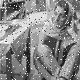

In [35]:
index=0
for i in range(80):
  for j in range(80):
    receiver_Image[i][j]=result[index]
    index+=1

cv2_imshow(receiver_Image)

#Sender side Image

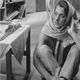

In [2]:
cv2_imshow(sender_Image)